## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [3]:
from PINN import prepare_UCI_dataset_w, get_dicrotic_notch, get_systolic_peak, get_delay_time, estimate_RC, grid_search_RC, train_resnet1d, create_data_loaders, run_windkessel_pinn, plot_training_loss,plot_pinn_training_metrics

In [4]:
wavelet = "db4"
level = 6
DATA_PATH = (f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}")

MAT_PATH = f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}/Part_1.mat"

In [5]:
FS = 125
WINDOW_SIZE = 1000


f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

# print("Number of recordings:", dataset.shape[0])
ref = dataset[1,0 ]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)


ppg = (ppg - np.mean(ppg)) / ppg_std # Normalize PPG signal
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================
def calculate_derivatives(ppg, fs=125):

    # -----------------------------------
    # Smooth PPG
    # -----------------------------------

    smooth_ppg = savgol_filter(
        ppg,
        window_length=15,
        polyorder=3
    )

    # -----------------------------------
    # First derivative = VPG
    # -----------------------------------

    vpg = np.gradient(
        smooth_ppg
    ) * fs

    # -----------------------------------
    # Second derivative = APG
    # -----------------------------------

    apg = np.gradient(
        vpg
    ) * fs

    return smooth_ppg, vpg, apg
notches = []

for sys_idx in sys_peaks:
    smooth_ppg, vpg, apg = calculate_derivatives(
            ppg_window,
            FS
        )
    

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        vpg,
        apg,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 15
Systolic peak indices: [ 54 119 184 249 312 377 442 507 569 633 698 761 824 886 950]

Detected landmarks:
Beat 1: Systolic = 54 (0.432 s), Notch = 74
Beat 2: Systolic = 119 (0.952 s), Notch = 138
Beat 3: Systolic = 184 (1.472 s), Notch = 203
Beat 4: Systolic = 249 (1.992 s), Notch = 267
Beat 5: Systolic = 312 (2.496 s), Notch = 333
Beat 6: Systolic = 377 (3.016 s), Notch = 397
Beat 7: Systolic = 442 (3.536 s), Notch = 461
Beat 8: Systolic = 507 (4.056 s), Notch = 526
Beat 9: Systolic = 569 (4.552 s), Notch = 588
Beat 10: Systolic = 633 (5.064 s), Notch = 652
Beat 11: Systolic = 698 (5.584 s), Notch = 717
Beat 12: Systolic = 761 (6.088 s), Notch = 783
Beat 13: Systolic = 824 (6.592 s), Notch = 844
Beat 14: Systolic = 886 (7.088 s), Notch = 907
Beat 15: Systolic = 950 (7.600 s), Notch = 970

Peak → notch delays:
Beat 1: 0.160 seconds
Beat 2: 0.152 seconds
Beat 3: 0.152 secon

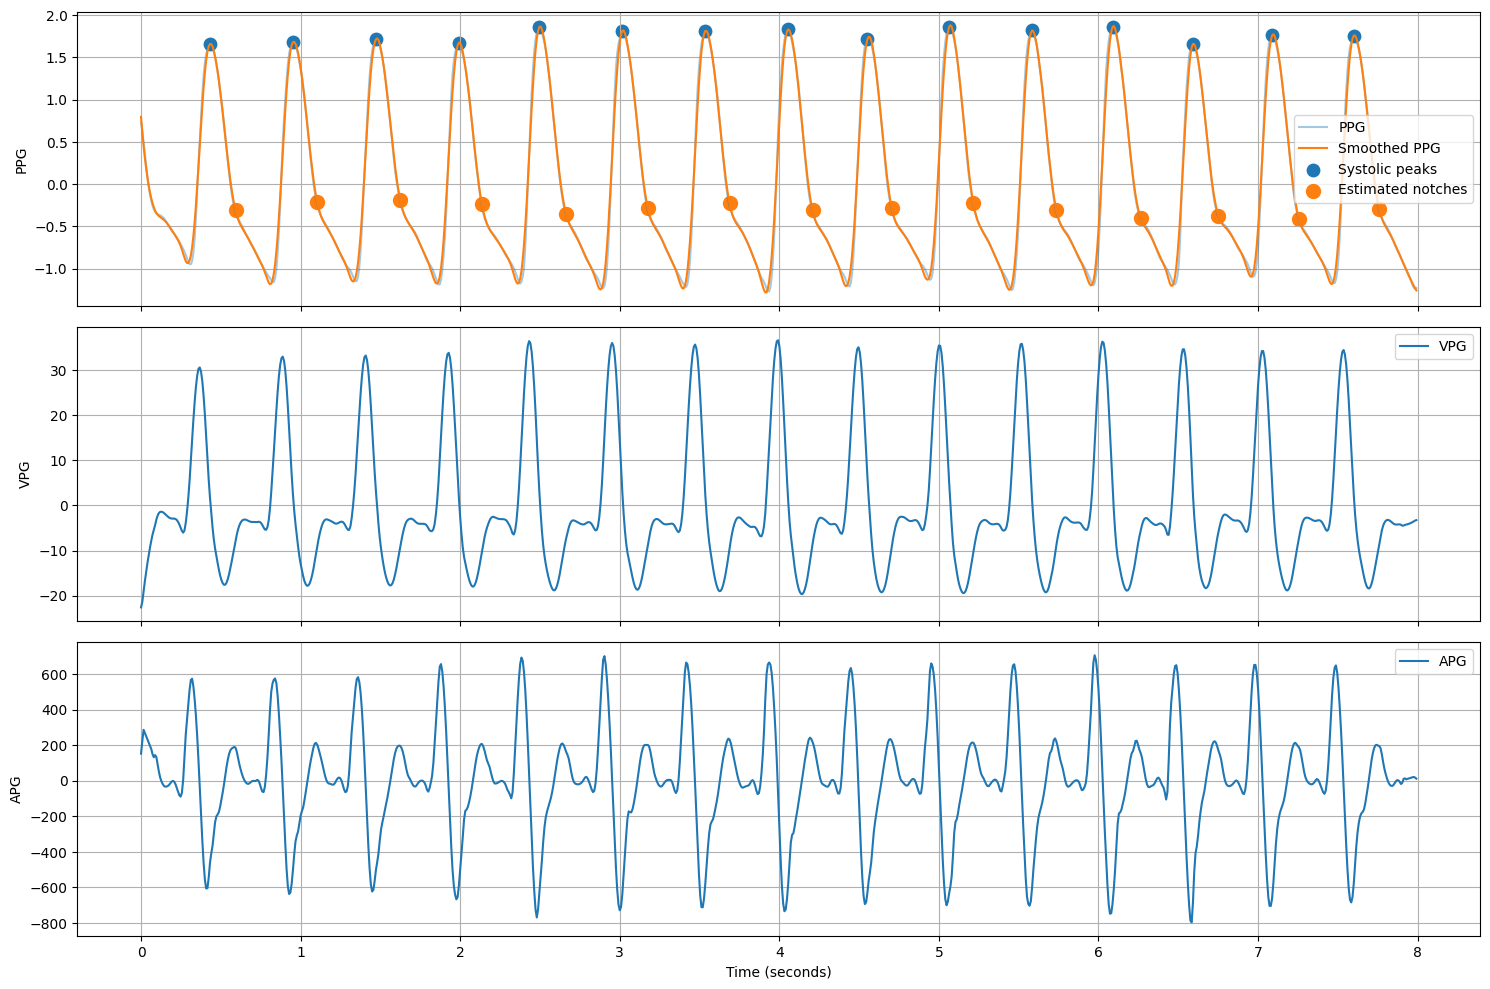

In [6]:
smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)
vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS


time = np.arange(
    len(ppg_window)
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [7]:
delay_time =  get_delay_time(ppg_window)
print(delay_time)

[0.16  0.152 0.152 0.144 0.168 0.16  0.152 0.152 0.152 0.152 0.152 0.176
 0.16  0.168 0.16 ]


In [8]:
X_train, y_train, delay_train, X_val, y_val, delay_val, X_test, y_test, delay_test = prepare_UCI_dataset_w(
    data_path=DATA_PATH, window_size=1000, step_size=1000)

Total recordings: 12000
Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400

Processing TRAIN recordings...


Processing recordings: 100%|██████████| 8400/8400 [06:25<00:00, 21.78it/s]


Skipped recordings: 94

Processing VALIDATION recordings...


Processing recordings: 100%|██████████| 1200/1200 [00:56<00:00, 21.26it/s]


Skipped recordings: 14

Processing TEST recordings...


Processing recordings: 100%|██████████| 2400/2400 [01:55<00:00, 20.73it/s]


Skipped recordings: 16

DATASET SHAPES
X_train: torch.Size([228913, 1, 1000])
y_train: torch.Size([228913, 2])
delay_train: torch.Size([228913])
X_val: torch.Size([33008, 1, 1000])
y_val: torch.Size([33008, 2])
delay_val: torch.Size([33008])
X_test: torch.Size([67302, 1, 1000])
y_test: torch.Size([67302, 2])
delay_test: torch.Size([67302])


In [9]:
print("Shape:", delay_train.shape)
print("Dtype:", delay_train.dtype)
print("NaN count:", np.isnan(delay_train).sum())
delay_train_np = delay_train.detach().cpu().numpy().astype(np.float32)
print(
    "NaN percentage:",
    100 * np.isnan(delay_train_np).mean(),
    "%"
)

valid_delay = delay_train_np[
    np.isfinite(delay_train_np)
]

print("Valid values:", len(valid_delay))

if len(valid_delay) > 0:

    print("\nStatistics:")

    print(
        "Min    :",
        np.min(valid_delay)
    )

    print(
        "Max    :",
        np.max(valid_delay)
    )

    print(
        "Mean   :",
        np.mean(valid_delay)
    )

    print(
        "Median :",
        np.median(valid_delay)
    )

    print(
        "Std    :",
        np.std(valid_delay)
    )

if len(valid_delay) > 0:

    print("\nRange checks:")

    print(
        "Below 0.08 s:",
        np.sum(valid_delay < 0.08)
    )

    print(
        "Above 0.35 s:",
        np.sum(valid_delay > 0.35)
    )

    print(
        "Within 0.08–0.35 s:",
        np.sum(
            (valid_delay >= 0.08) &
            (valid_delay <= 0.35)
        )
    )


if len(valid_delay) > 0:

    print("\nPercentiles:")

    for p in [1, 5, 25, 50, 75, 95, 99]:

        print(
            f"{p:2d}% :",
            np.percentile(valid_delay, p)
        )

Shape: torch.Size([228913])
Dtype: torch.float32
NaN count: tensor(0)
NaN percentage: 0.0 %
Valid values: 228913

Statistics:
Min    : 0.088
Max    : 0.336
Mean   : 0.18188834
Median : 0.18
Std    : 0.036330793

Range checks:
Below 0.08 s: 0
Above 0.35 s: 0
Within 0.08–0.35 s: 228913

Percentiles:
 1% : 0.112
 5% : 0.128
25% : 0.152
50% : 0.18
75% : 0.208
95% : 0.24399999
99% : 0.28


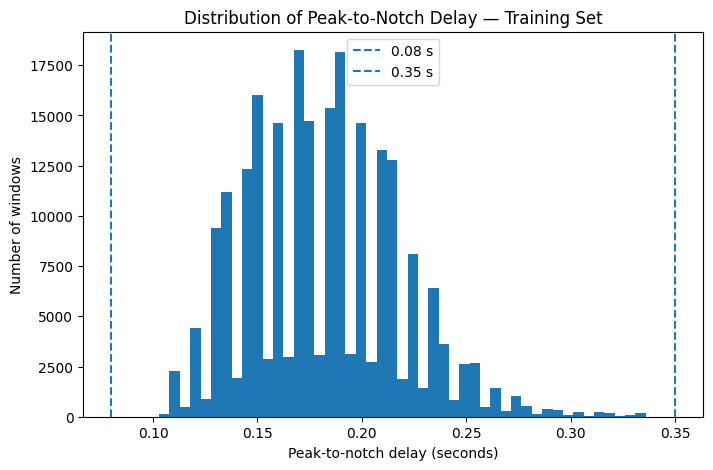

In [10]:
import matplotlib.pyplot as plt

valid_delay = delay_train[
    np.isfinite(delay_train)
]

plt.figure(figsize=(8, 5))

plt.hist(
    valid_delay,
    bins=50
)

plt.xlabel("Peak-to-notch delay (seconds)")
plt.ylabel("Number of windows")
plt.title("Distribution of Peak-to-Notch Delay — Training Set")

plt.axvline(
    0.08,
    linestyle="--",
    label="0.08 s"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="0.35 s"
)

plt.legend()

plt.show()

In [11]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("delay_train:", delay_train.shape)

print(
    "Number of windows:",
    len(X_train)
)

print(
    "Number of BP labels:",
    len(y_train)
)

print(
    "Number of delays:",
    len(delay_train)
)

X_train: torch.Size([228913, 1, 1000])
y_train: torch.Size([228913, 2])
delay_train: torch.Size([228913])
Number of windows: 228913
Number of BP labels: 228913
Number of delays: 228913


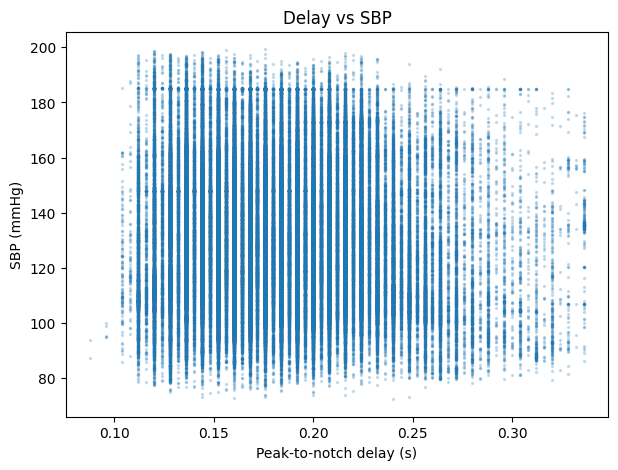

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 0],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("SBP (mmHg)")
plt.title("Delay vs SBP")

plt.show()

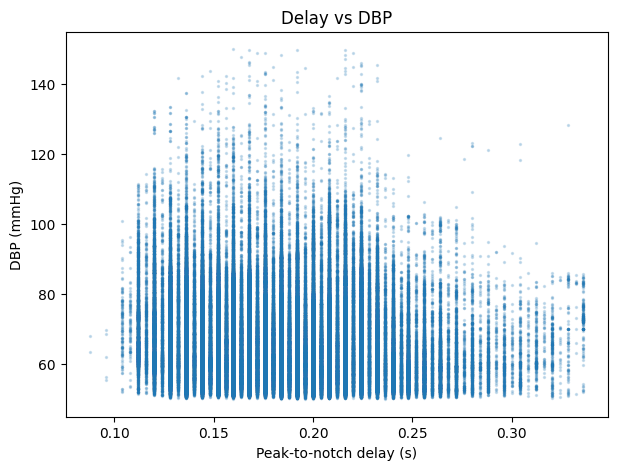

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 1],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("DBP (mmHg)")
plt.title("Delay vs DBP")

plt.show()

## RC Estimation ##

In [14]:
RC, RC_values = estimate_RC(
    sbp=y_train[:, 0].numpy(),
    dbp=y_train[:, 1].numpy(),
    delay=delay_train
)

Total windows: 228913
Valid windows: 228913
Valid percentage: 100.0 %

Windkessel RC Estimation
Median RC : 0.2688 s
Mean RC   : 0.2910 s
Std RC    : 0.1104 s
Min RC    : 0.1139 s
Max RC    : 1.5369 s


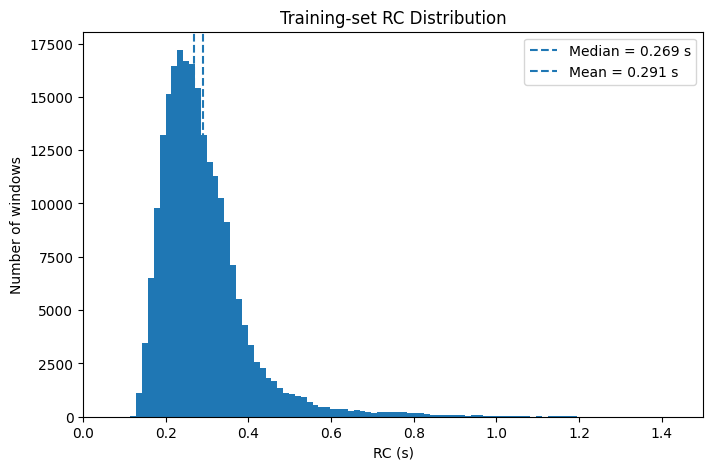

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    RC_values,
    bins=100
)

plt.axvline(
    np.median(RC_values),
    linestyle="--",
    label=f"Median = {np.median(RC_values):.3f} s"
)
plt.axvline(
    np.mean(RC_values),
    linestyle="--",
    label=f"Mean = {np.mean(RC_values):.3f} s"
)

plt.xlabel("RC (s)")
plt.xlim(0,1.5)
plt.ylabel("Number of windows")
plt.title("Training-set RC Distribution")
plt.legend()

plt.show()

It's a highly skewed distribution, so using mean won't be a good idea

In [16]:
for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(RC_values, p):.4f} s"
    )

  1.0% : 0.1483 s
  5.0% : 0.1713 s
 25.0% : 0.2204 s
 50.0% : 0.2688 s
 75.0% : 0.3322 s
 90.0% : 0.4050 s
 95.0% : 0.4839 s
 99.0% : 0.7432 s
 99.5% : 0.8282 s
 99.9% : 1.0511 s


In [17]:
RC = 0.2994

sbp = y_train[:, 0].cpu().numpy()
dbp = y_train[:, 1].cpu().numpy()
delay = delay_train.cpu().numpy()

dbp_physics = (
    sbp *
    np.exp(-delay / RC)
)

physics_mae = np.mean(
    np.abs(dbp_physics - dbp)
)

physics_rmse = np.sqrt(
    np.mean(
        (dbp_physics - dbp) ** 2
    )
)

print("Physics-only DBP MAE :", physics_mae)
print("Physics-only DBP RMSE:", physics_rmse)

Physics-only DBP MAE : 11.381126
Physics-only DBP RMSE: 14.531796


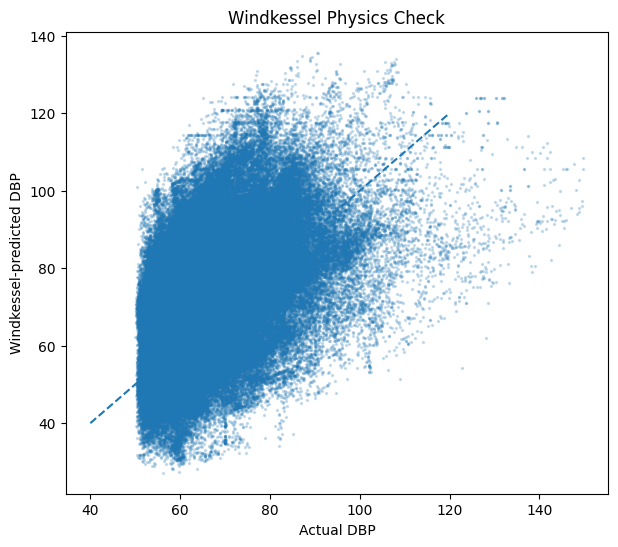

In [18]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dbp,
    dbp_physics,
    s=2,
    alpha=0.2
)

plt.plot(
    [40, 120],
    [40, 120],
    linestyle="--"
)

plt.xlabel("Actual DBP")
plt.ylabel("Windkessel-predicted DBP")
plt.title("Windkessel Physics Check")

plt.show()

In [19]:
rc_values, mae_values, rmse_values, best_RC_MAE, best_RC_RMSE = grid_search_RC(
    sbp=y_train[:, 0].cpu().numpy(),
    dbp=y_train[:, 1].cpu().numpy(),
    delay=delay_train.cpu().numpy(),
    rc_min=0.10,
    rc_max=1.00,
    rc_step=0.005
)
RC = best_RC_MAE

Valid samples: 228913

RC GRID SEARCH RESULTS
Best RC by MAE  : 0.2650 s
Best MAE        : 10.6260 mmHg

Best RC by RMSE : 0.2650 s
Best RMSE       : 13.4955 mmHg


## Establishing Baseline using 1D ResNet ##

In [20]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([228913, 1, 1000])
y_train: torch.Size([228913, 2])
X_val: torch.Size([33008, 1, 1000])
y_val: torch.Size([33008, 2])
X_test: torch.Size([67302, 1, 1000])
y_test: torch.Size([67302, 2])


In [22]:
train_loader, val_loader, test_loader = create_data_loaders(
    X_train, y_train,
    X_val, y_val,  
    X_test, y_test)


Epoch [01/50] LR: 1.00e-04 | Train MSE: 7699.1570 | Train SBP MSE: 12706.9672 | Train DBP MSE: 2691.3469 | Train SBP RMSE: 112.7252 | Train DBP RMSE: 51.8782 | Val MSE: 4737.6839 | Val SBP MSE: 8434.9812 | Val DBP MSE: 1040.3866 | Val SBP RMSE: 91.8422 | Val DBP RMSE: 32.2550
Epoch [02/50] LR: 1.00e-04 | Train MSE: 2831.8096 | Train SBP MSE: 5231.8545 | Train DBP MSE: 431.7647 | Train SBP RMSE: 72.3316 | Train DBP RMSE: 20.7789 | Val MSE: 1455.2900 | Val SBP MSE: 2785.4053 | Val DBP MSE: 125.1746 | Val SBP RMSE: 52.7769 | Val DBP RMSE: 11.1881
Epoch [03/50] LR: 1.00e-04 | Train MSE: 677.6838 | Train SBP MSE: 1237.1055 | Train DBP MSE: 118.2621 | Train SBP RMSE: 35.1725 | Train DBP RMSE: 10.8748 | Val MSE: 263.3477 | Val SBP MSE: 403.8660 | Val DBP MSE: 122.8293 | Val SBP RMSE: 20.0964 | Val DBP RMSE: 11.0828
Epoch [04/50] LR: 1.00e-04 | Train MSE: 255.8511 | Train SBP MSE: 401.8574 | Train DBP MSE: 109.8449 | Train SBP RMSE: 20.0464 | Train DBP RMSE: 10.4807 | Val MSE: 233.6856 | Val S

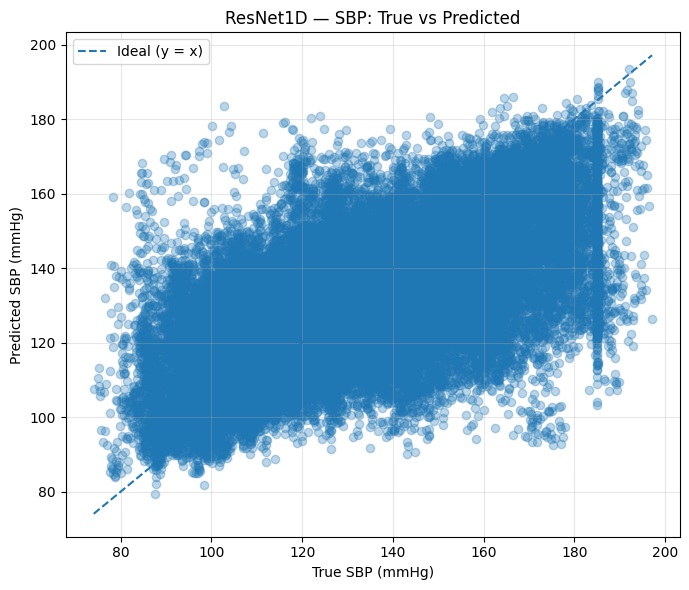

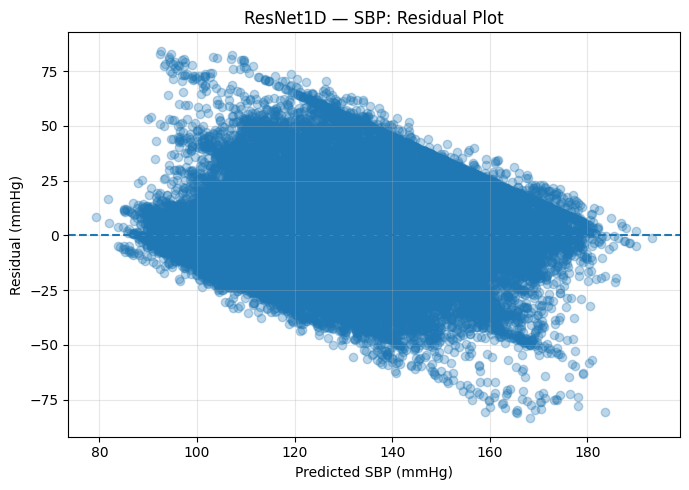

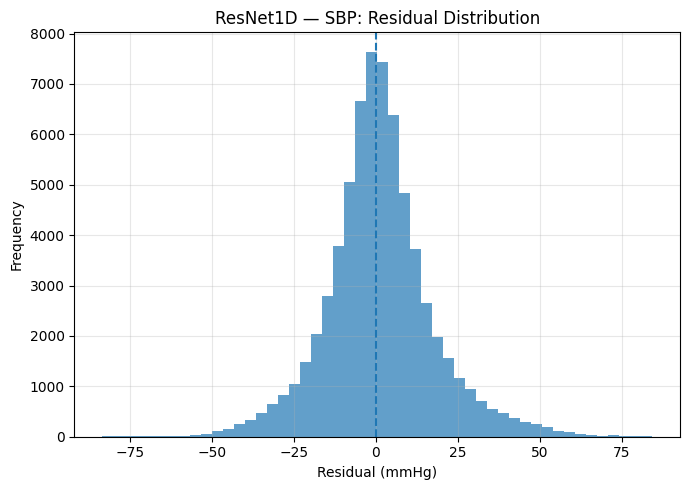

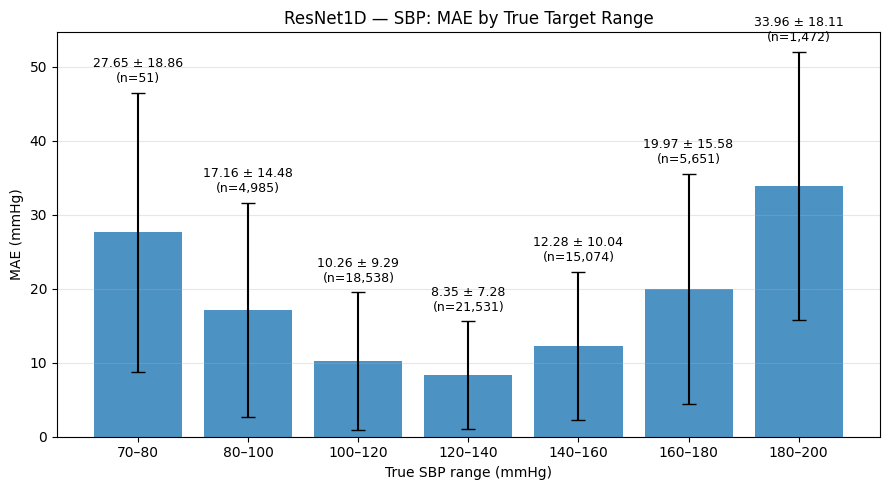



DBP TEST RESULTS
RMSE: 8.6911
MSE : 75.5361
R²  : 0.3911
MAE : 5.9602


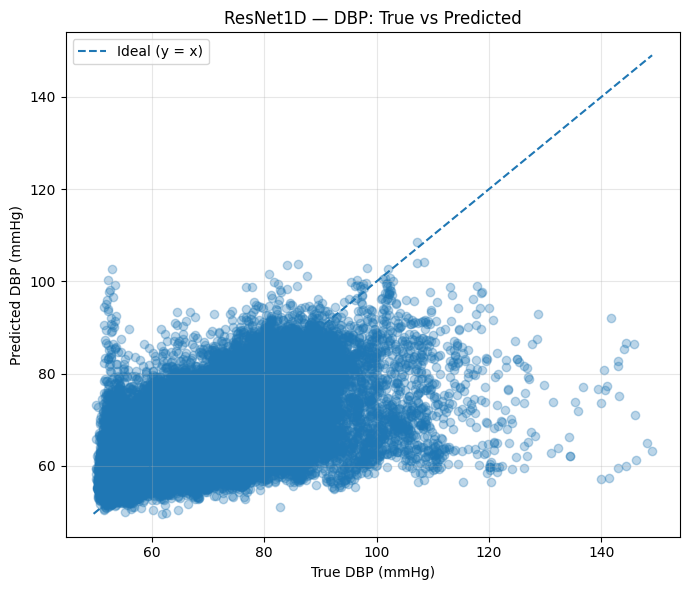

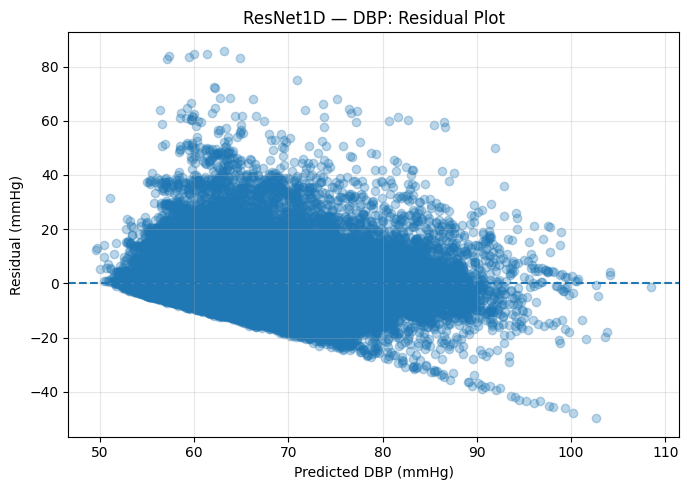

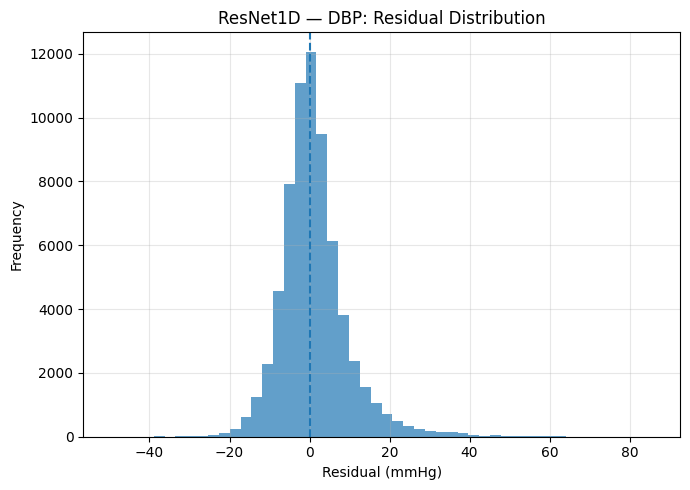

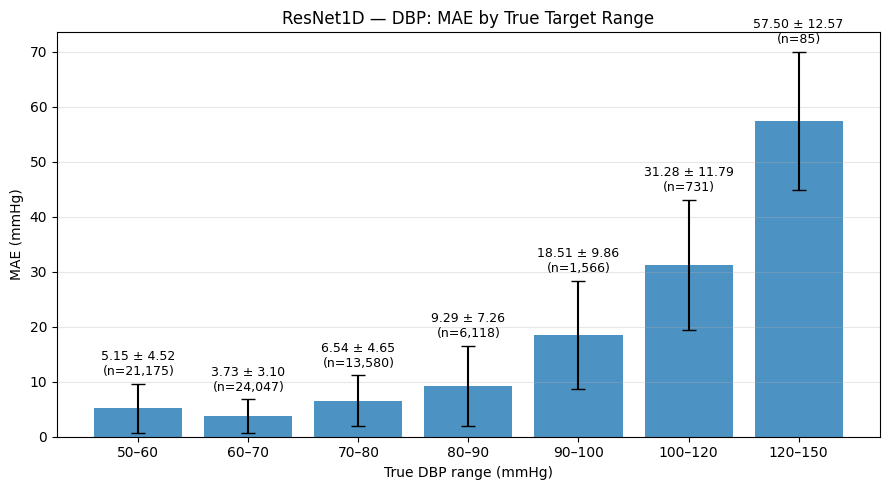

In [23]:
model, history, y_true, y_pred = train_resnet1d(
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=50
)

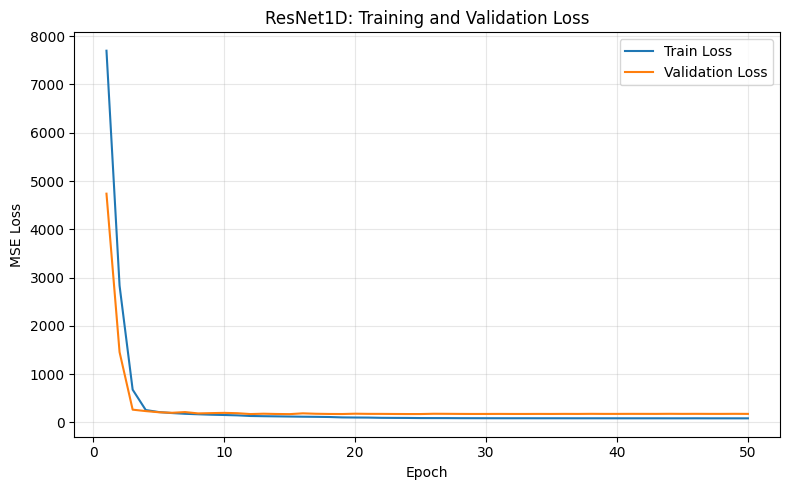

In [24]:
plot_training_loss(
    history,
    model_name="ResNet1D"
)

## Physics Informed Windkessel ##

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15600.5622 | Train SBP MSE: 12872.0891 | Train DBP MSE: 2728.4658 | Train Phys: 73.1391 | Train RMSE: SBP=113.455, DBP=52.235 | Val Total: 10314.1816 | Val SBP MSE: 9152.1230 | Val DBP MSE: 1162.0355 | Val Phys: 230.3928 | Val RMSE: SBP=95.667, DBP=34.089 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5353.0316 | Train SBP MSE: 4984.2082 | Train DBP MSE: 368.7782 | Train Phys: 452.4571 | Train RMSE: SBP=70.599, DBP=19.204 | Val Total: 1618.8112 | Val SBP MSE: 1507.7758 | Val DBP MSE: 110.9896 | Val Phys: 459.0591 | Val RMSE: SBP=38.830, DBP=10.535 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 957.3987 | Train SBP MSE: 852.8905 | Train DBP MSE: 104.4875 | Train Phys: 207.3232 | Train RMSE: SBP=29.204, DBP=10.222 | Val Total: 462.1372 | Val SBP MSE: 365.2457 | Val DBP MSE: 96.8831 | Val Phys: 83.9501 | Val RMSE: SBP=19.111, DBP=9.843 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 437.2271 | Train SBP MSE: 337.9250 | Train DBP MSE: 99.29

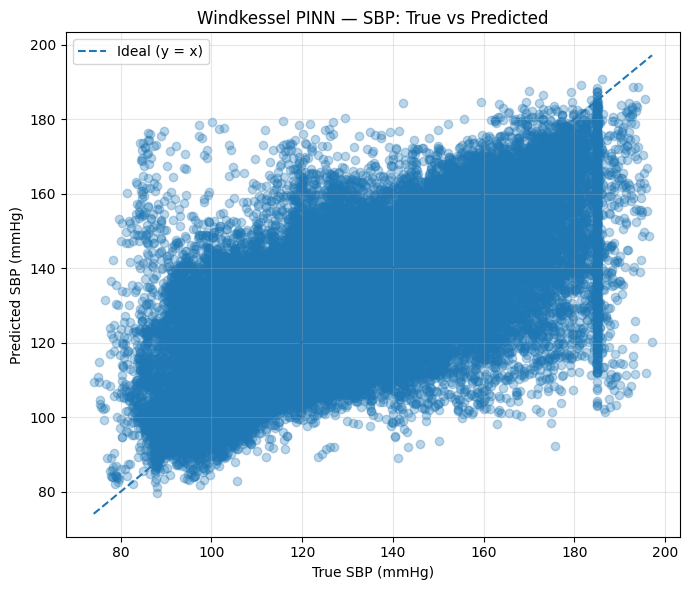

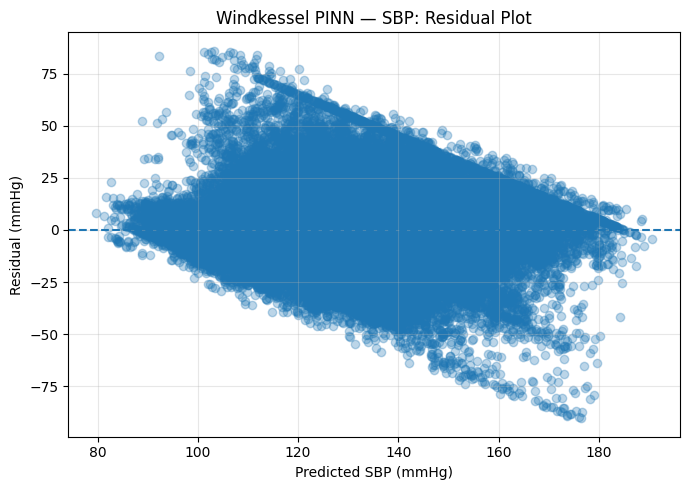

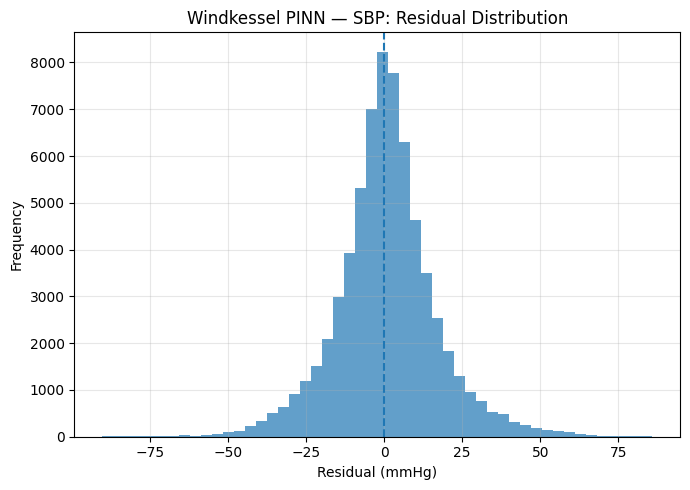

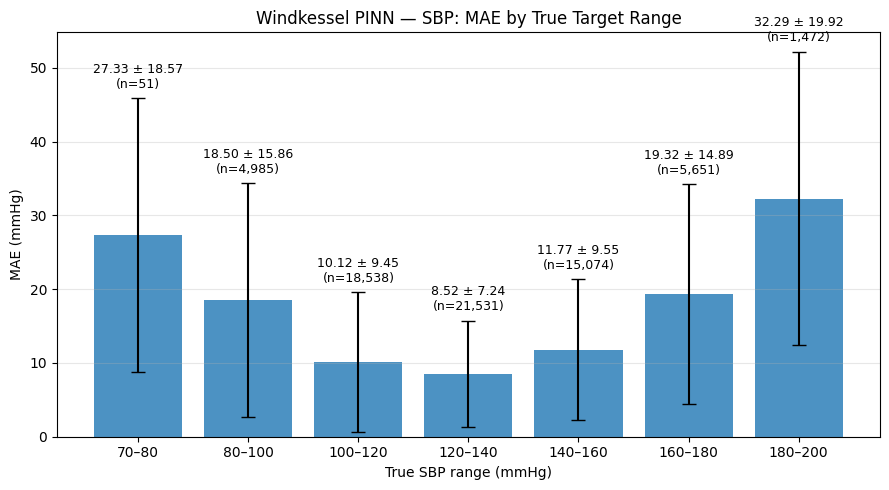


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.8045
MSE : 77.5189
R²  : 0.3751
MAE : 6.1668


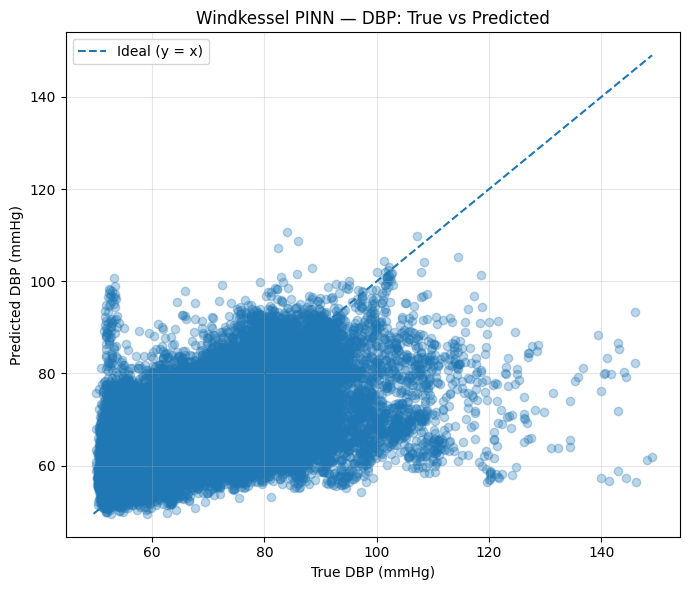

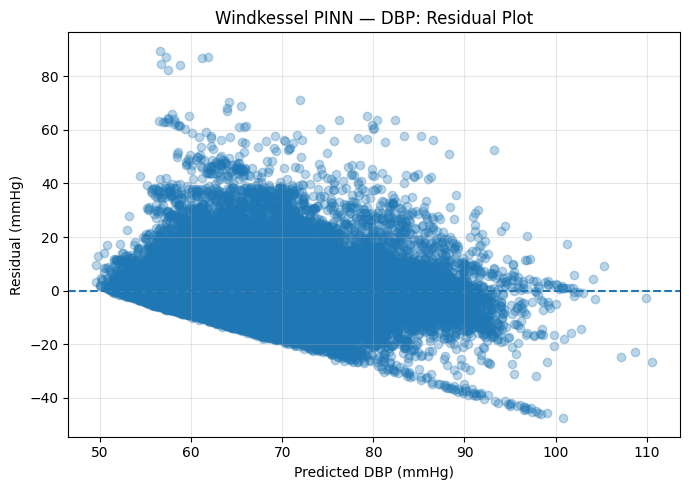

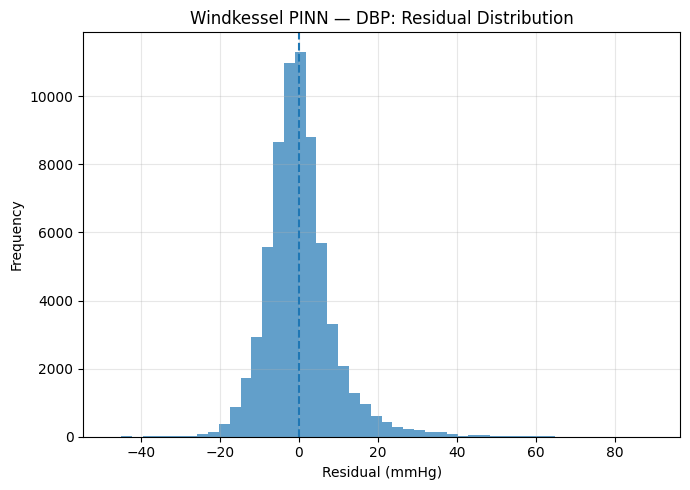

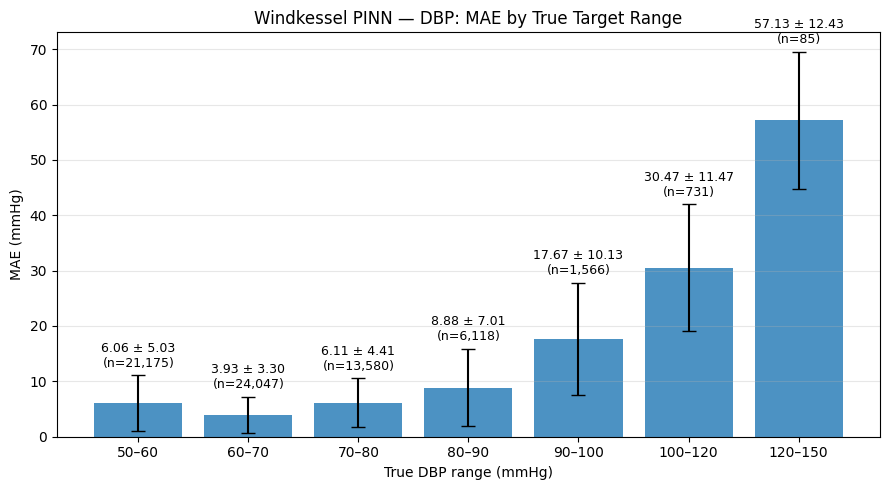

In [25]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.0001
)

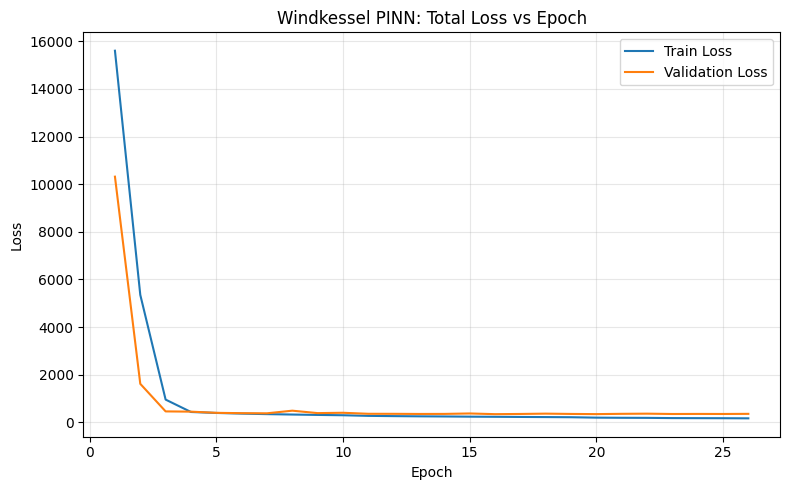

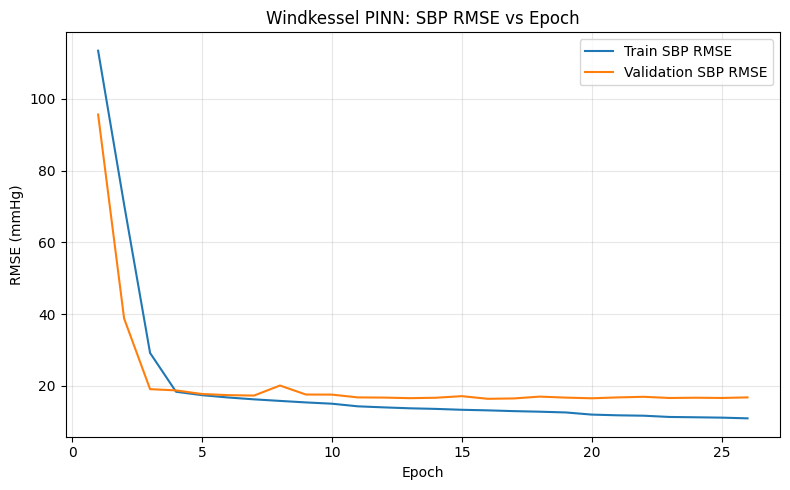

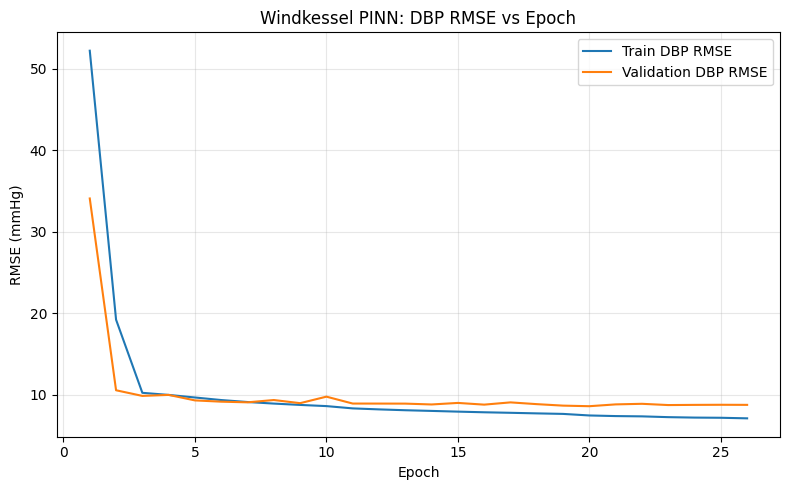

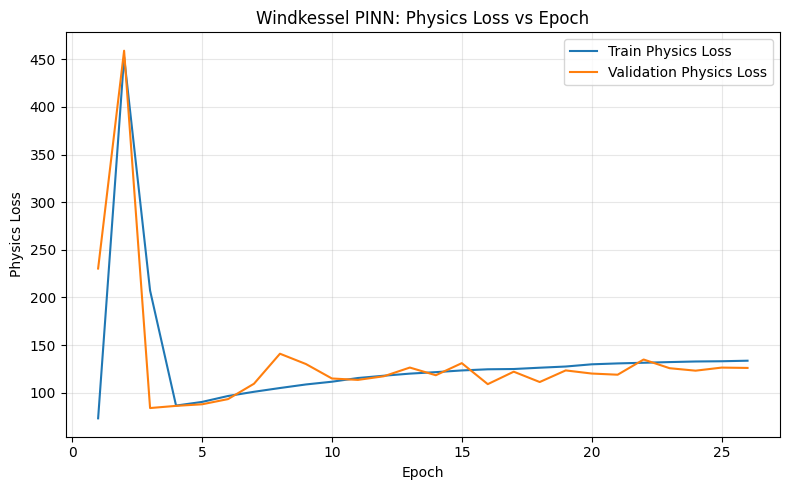

In [26]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15939.3629 | Train SBP MSE: 13024.9507 | Train DBP MSE: 2914.3678 | Train Phys: 44.3740 | Train RMSE: SBP=114.127, DBP=53.985 | Val Total: 10194.4456 | Val SBP MSE: 8913.9604 | Val DBP MSE: 1280.3208 | Val Phys: 164.4803 | Val RMSE: SBP=94.414, DBP=35.782 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5943.3930 | Train SBP MSE: 5431.0591 | Train DBP MSE: 511.9746 | Train Phys: 359.2820 | Train RMSE: SBP=73.696, DBP=22.627 | Val Total: 2421.2423 | Val SBP MSE: 2318.8811 | Val DBP MSE: 101.9421 | Val Phys: 419.1060 | Val RMSE: SBP=48.155, DBP=10.097 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1086.8572 | Train SBP MSE: 980.9079 | Train DBP MSE: 105.7240 | Train Phys: 225.3854 | Train RMSE: SBP=31.319, DBP=10.282 | Val Total: 453.7822 | Val SBP MSE: 344.4790 | Val DBP MSE: 109.2152 | Val Phys: 87.9455 | Val RMSE: SBP=18.560, DBP=10.451 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 435.7732 | Train SBP MSE: 335.4322 | Train DBP MSE: 10

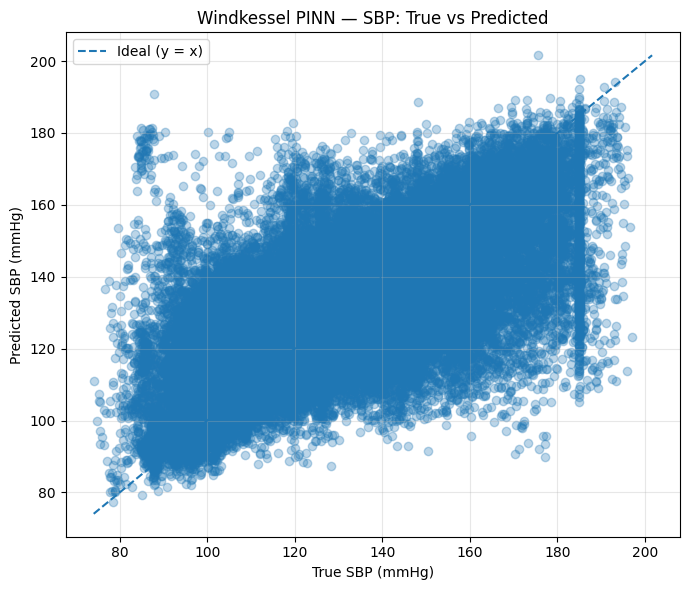

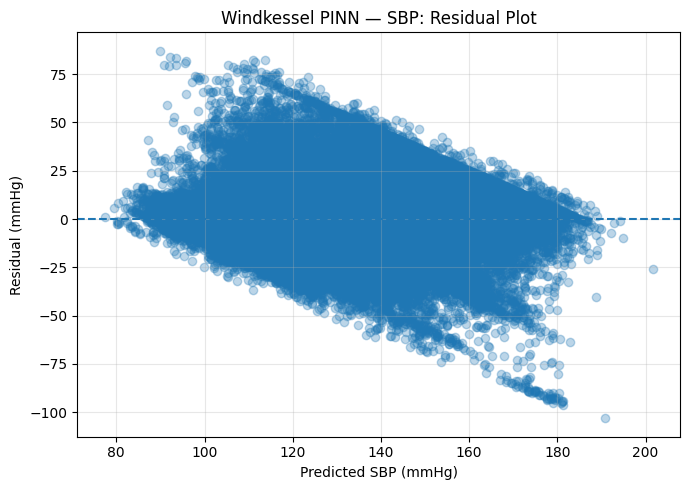

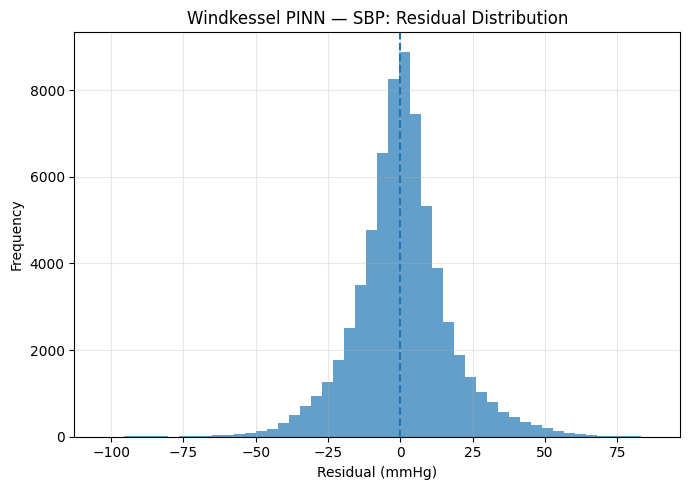

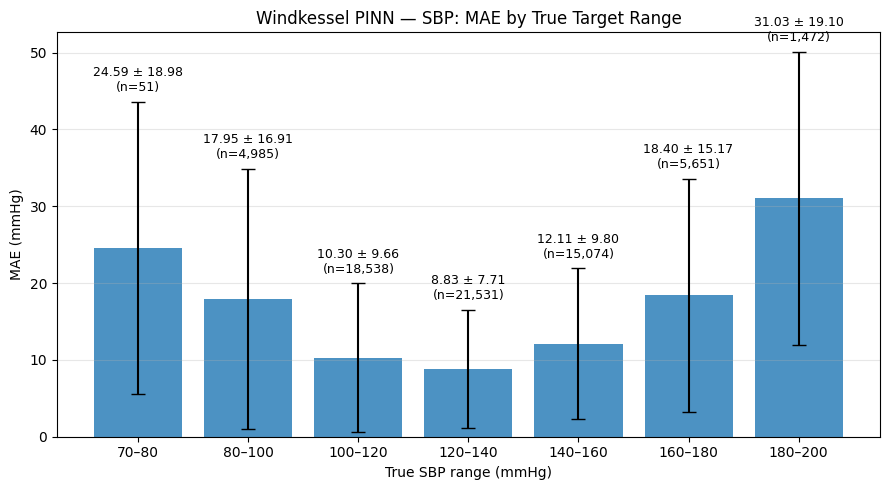


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.7120
MSE : 75.8988
R²  : 0.3882
MAE : 5.9773


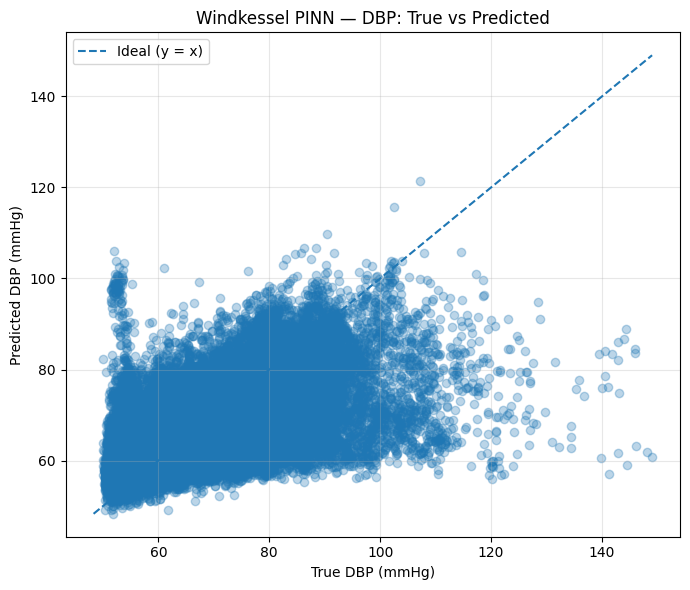

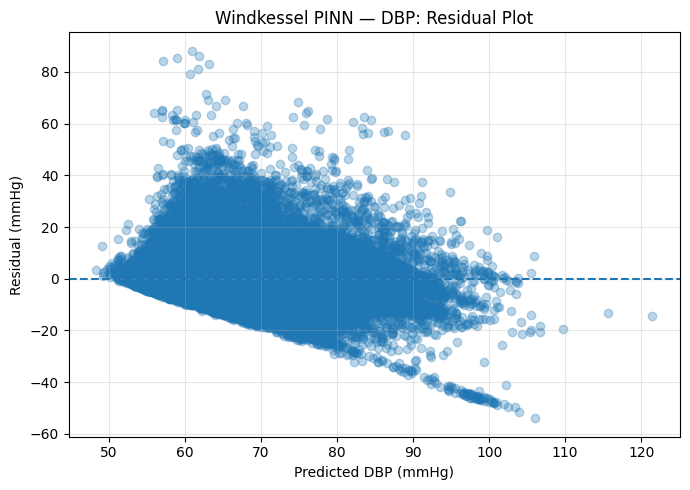

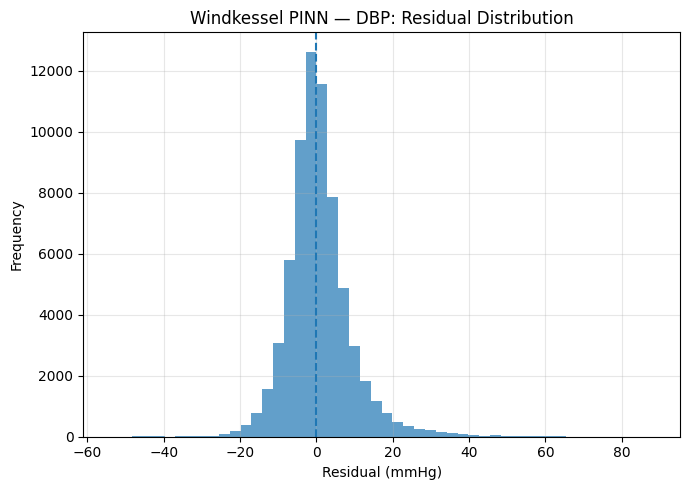

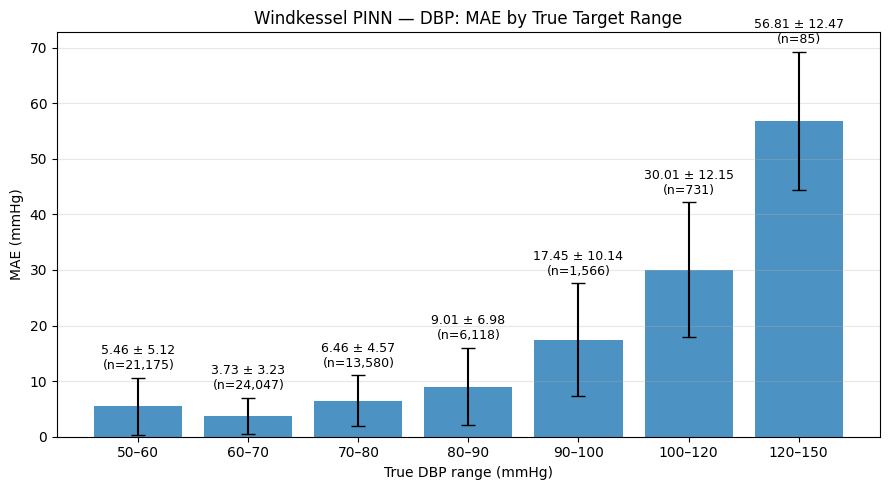

In [27]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.001
)

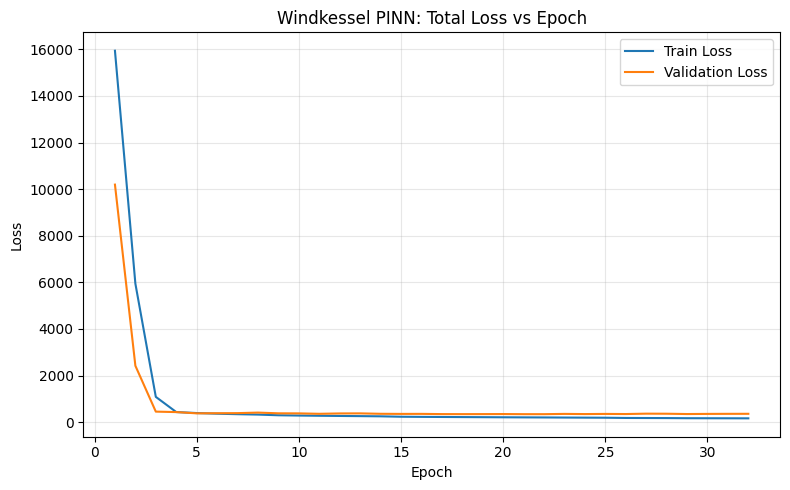

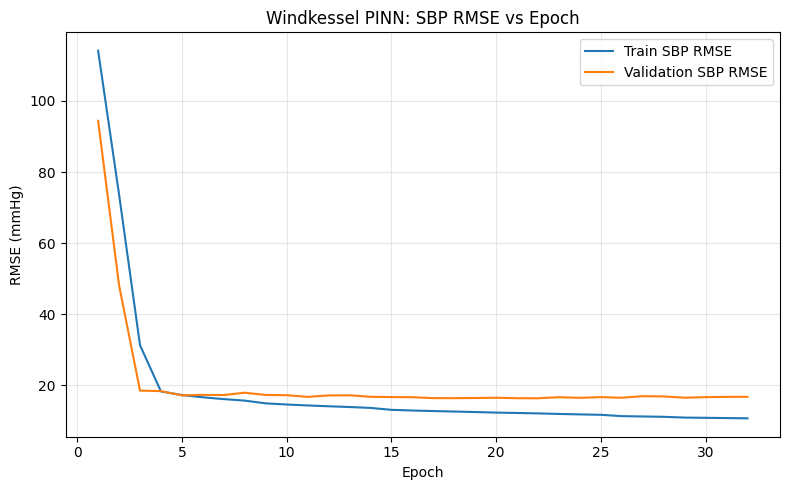

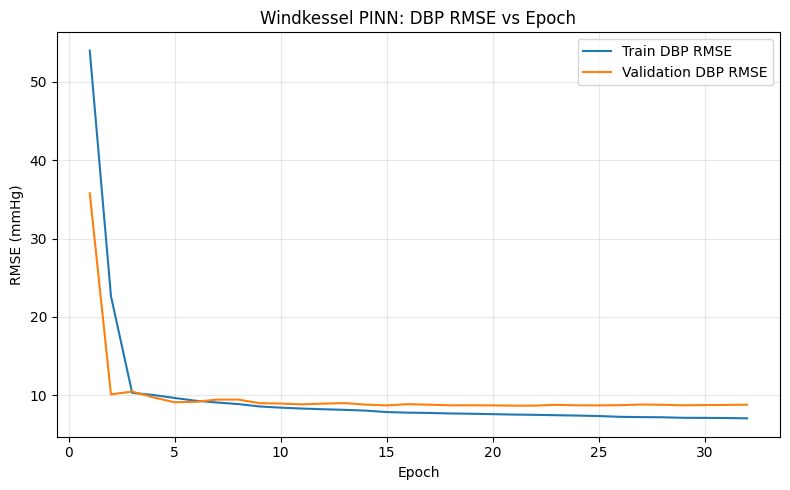

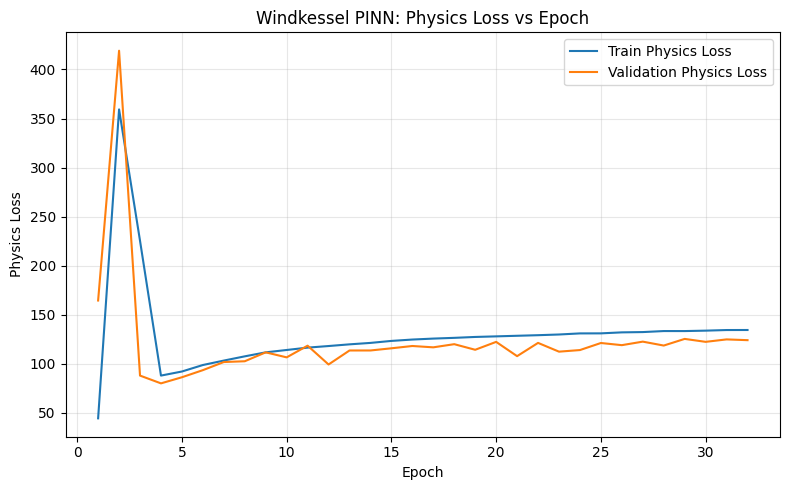

In [28]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15921.7129 | Train SBP MSE: 12976.0003 | Train DBP MSE: 2945.2598 | Train Phys: 45.2808 | Train RMSE: SBP=113.912, DBP=54.270 | Val Total: 10720.6371 | Val SBP MSE: 9231.6982 | Val DBP MSE: 1487.6876 | Val Phys: 125.1222 | Val RMSE: SBP=96.082, DBP=38.571 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6561.8475 | Train SBP MSE: 5935.7006 | Train DBP MSE: 622.8849 | Train Phys: 326.1940 | Train RMSE: SBP=77.043, DBP=24.958 | Val Total: 3967.1213 | Val SBP MSE: 3749.3616 | Val DBP MSE: 213.8901 | Val Phys: 386.9576 | Val RMSE: SBP=61.232, DBP=14.625 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1639.7641 | Train SBP MSE: 1513.3104 | Train DBP MSE: 123.3797 | Train Phys: 307.3979 | Train RMSE: SBP=38.901, DBP=11.108 | Val Total: 682.8631 | Val SBP MSE: 577.8067 | Val DBP MSE: 103.6457 | Val Phys: 141.0686 | Val RMSE: SBP=24.038, DBP=10.181 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 551.9709 | Train SBP MSE: 438.6806 | Train DBP MSE: 

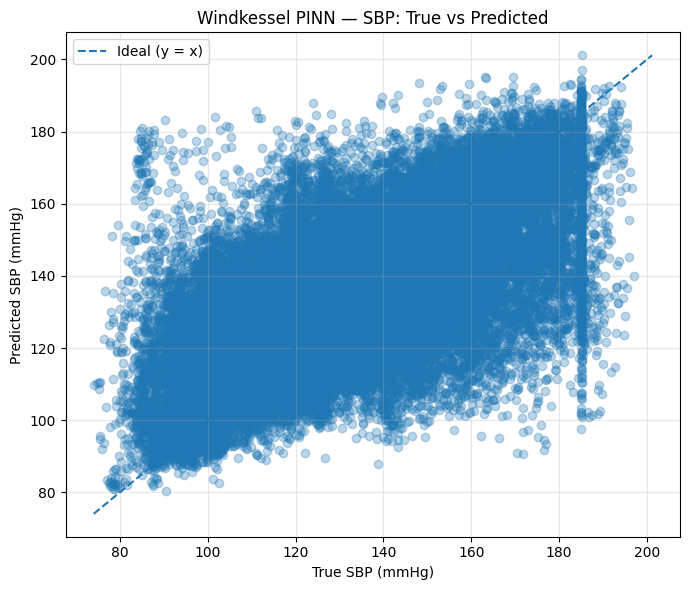

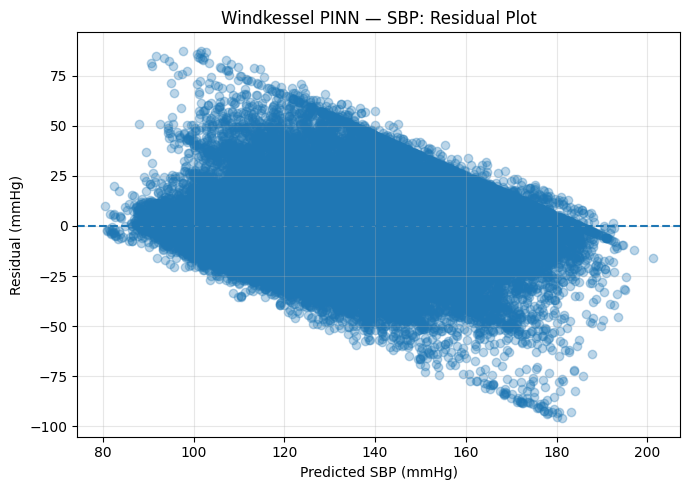

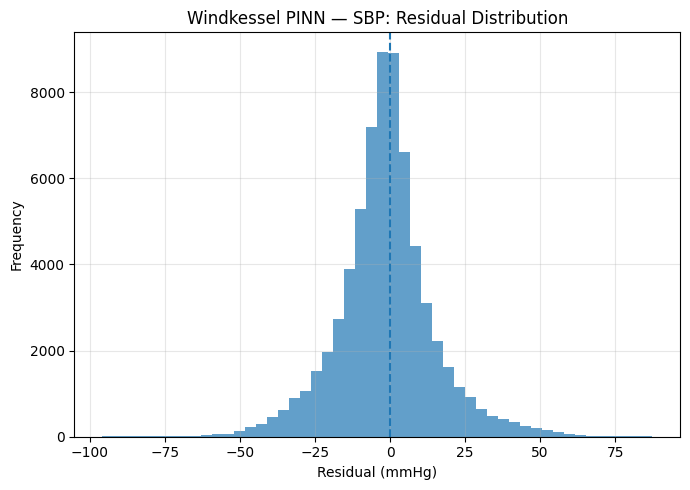

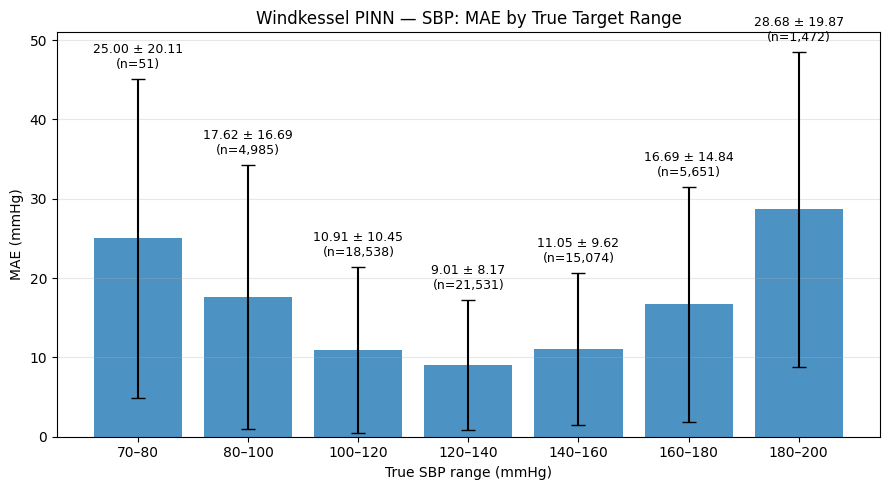


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.6546
MSE : 74.9018
R²  : 0.3962
MAE : 5.9767


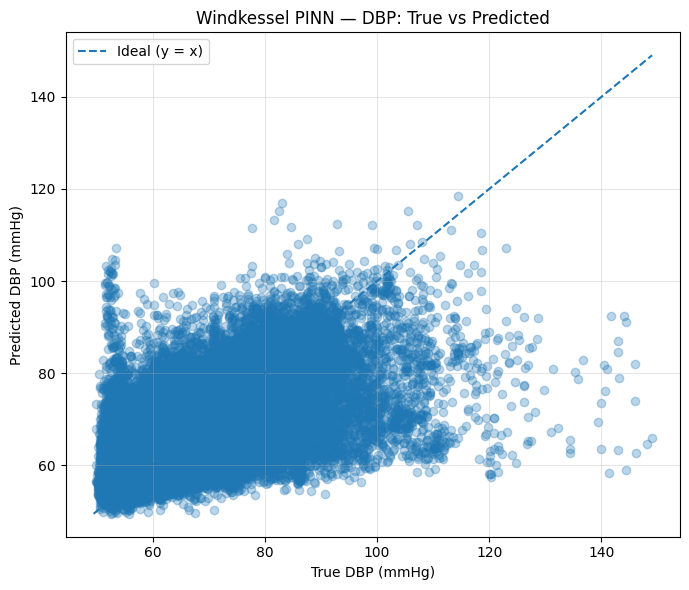

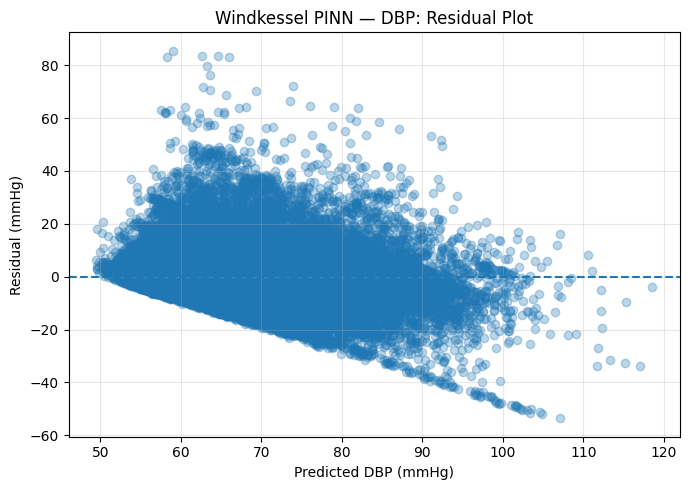

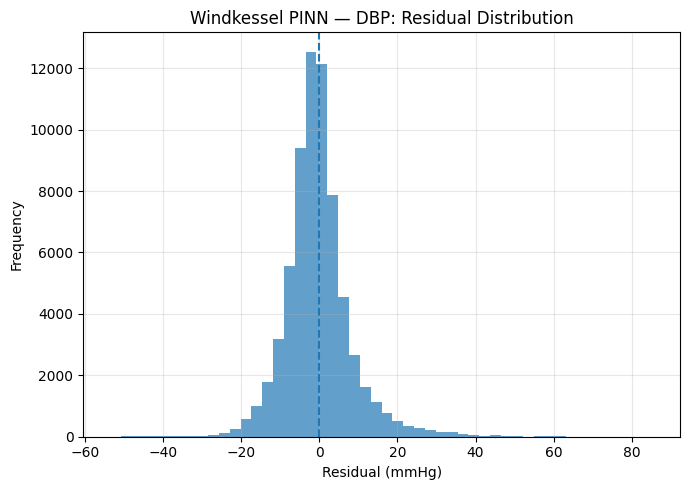

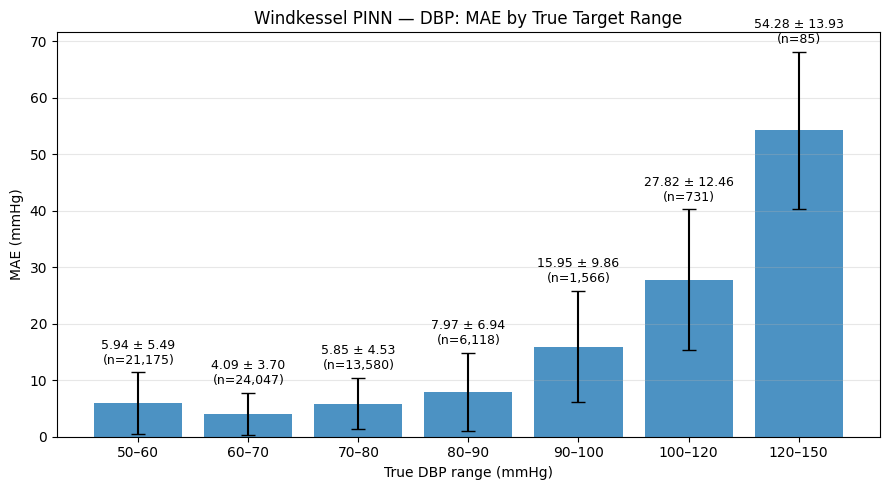

In [29]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.01
)

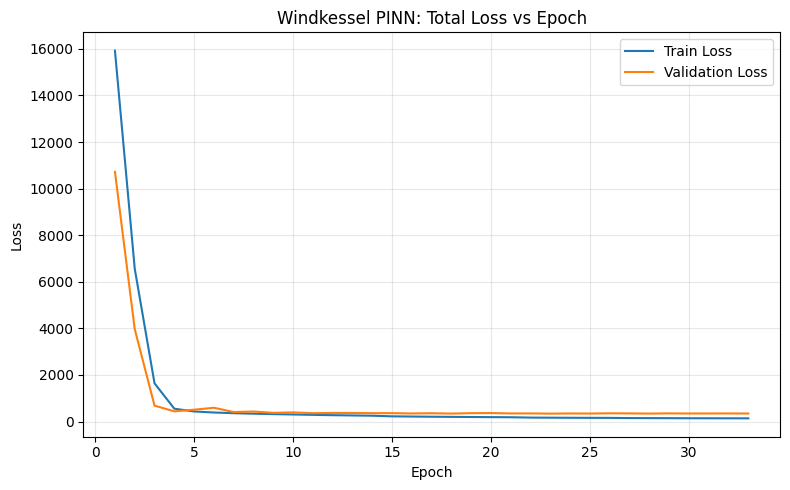

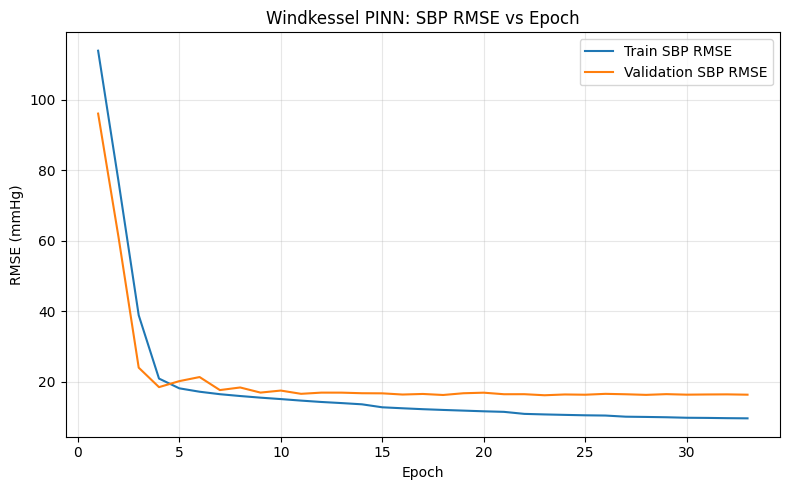

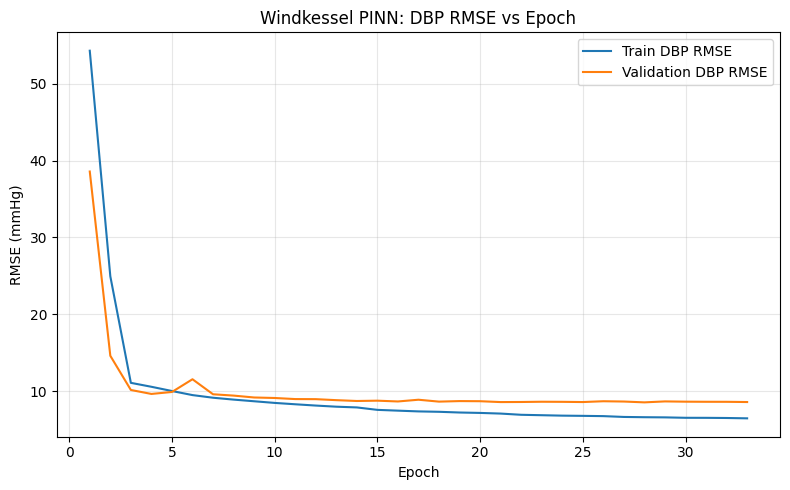

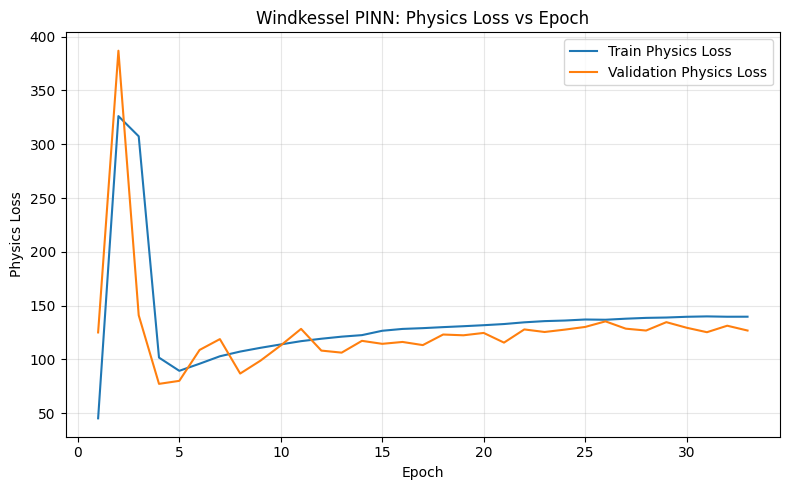

In [30]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15373.2328 | Train SBP MSE: 12653.3337 | Train DBP MSE: 2712.8535 | Train Phys: 70.4564 | Train RMSE: SBP=112.487, DBP=52.085 | Val Total: 9398.1620 | Val SBP MSE: 8381.1878 | Val DBP MSE: 990.8398 | Val Phys: 261.3449 | Val RMSE: SBP=91.549, DBP=31.478 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5214.3673 | Train SBP MSE: 4788.5181 | Train DBP MSE: 386.7860 | Train Phys: 390.6323 | Train RMSE: SBP=69.199, DBP=19.667 | Val Total: 1840.8067 | Val SBP MSE: 1709.7106 | Val DBP MSE: 100.0924 | Val Phys: 310.0365 | Val RMSE: SBP=41.349, DBP=10.005 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 883.1191 | Train SBP MSE: 759.6022 | Train DBP MSE: 107.3465 | Train Phys: 161.7041 | Train RMSE: SBP=27.561, DBP=10.361 | Val Total: 481.6085 | Val SBP MSE: 374.6291 | Val DBP MSE: 99.1268 | Val Phys: 78.5261 | Val RMSE: SBP=19.355, DBP=9.956 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 445.7403 | Train SBP MSE: 335.0628 | Train DBP MSE: 102.144

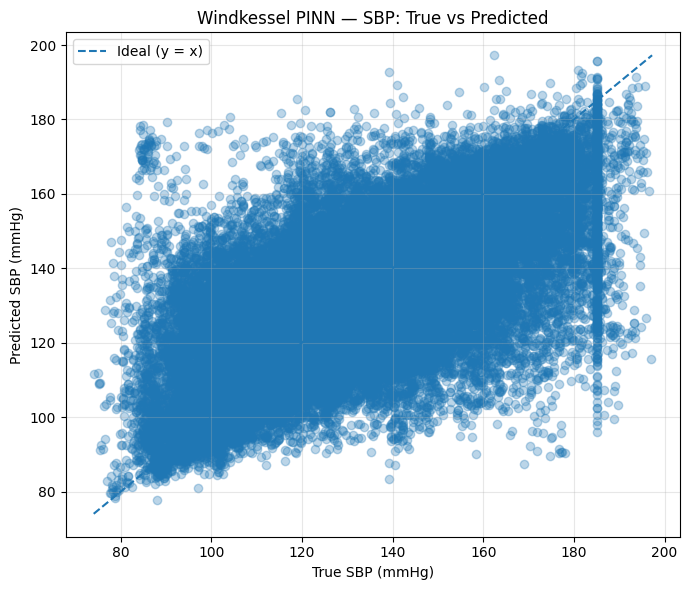

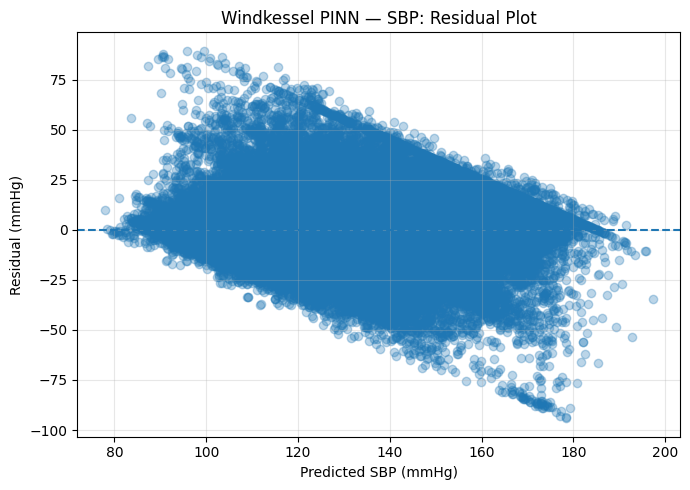

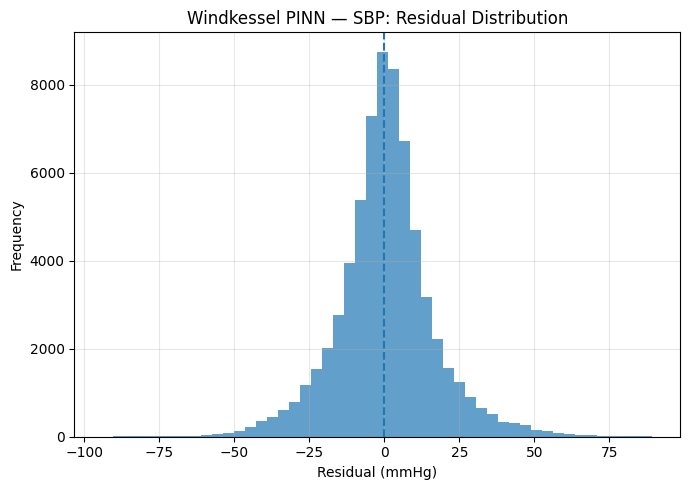

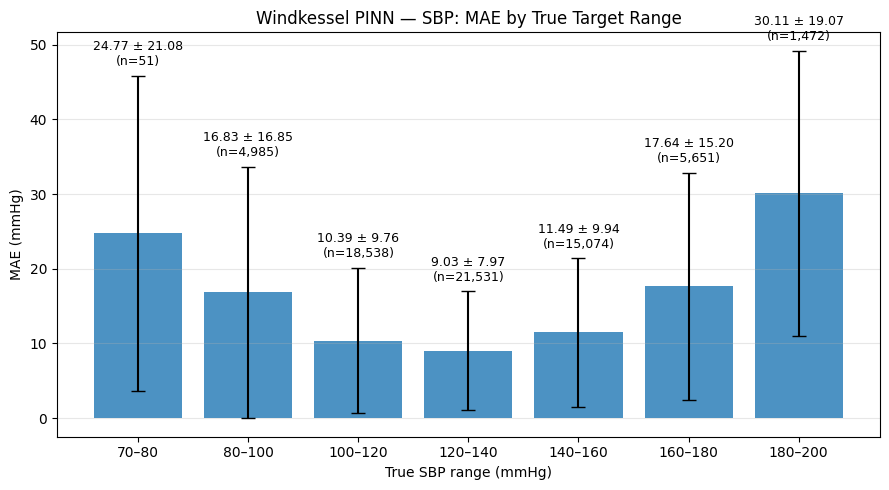


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.7775
MSE : 77.0441
R²  : 0.3789
MAE : 6.1331


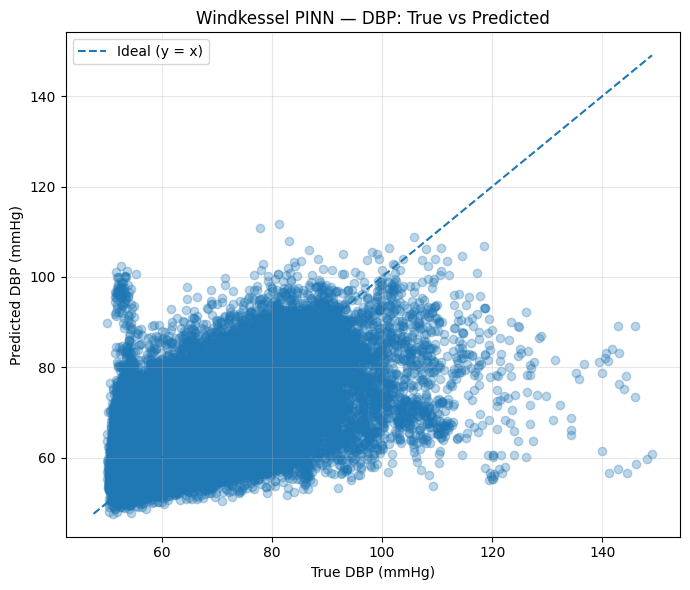

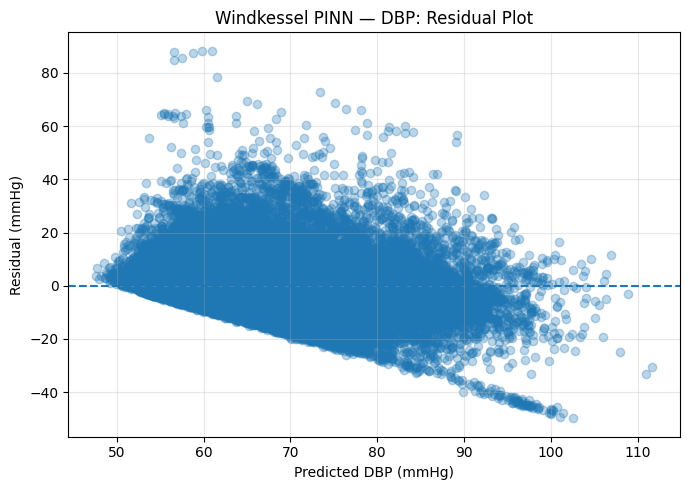

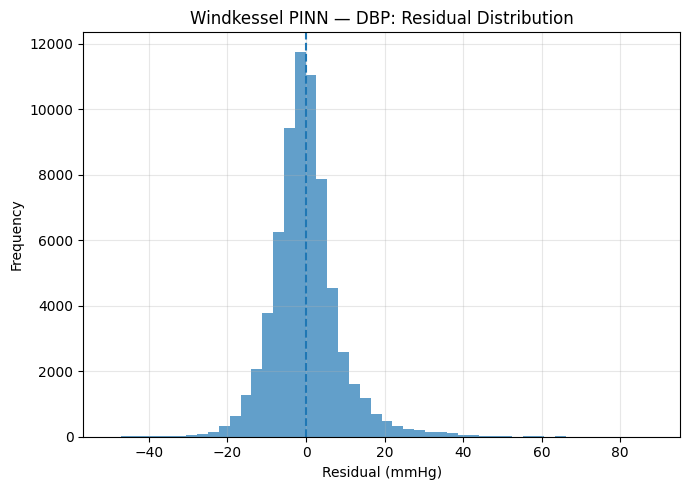

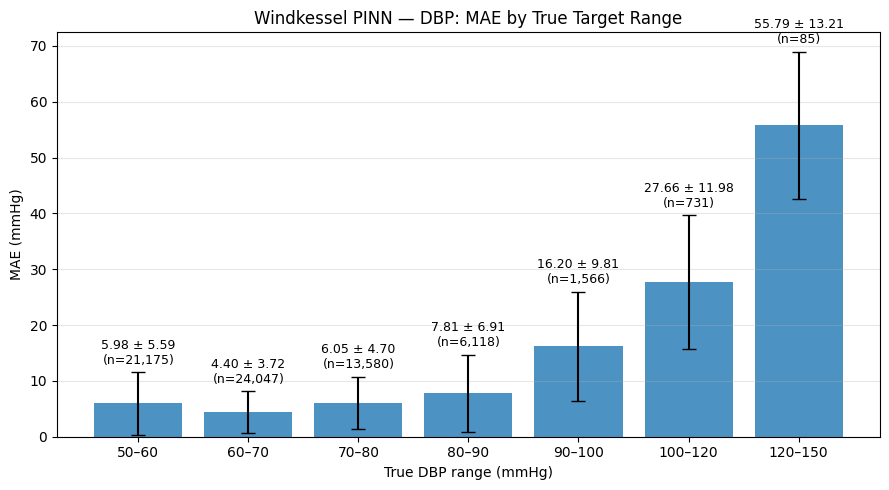

In [31]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.1
)

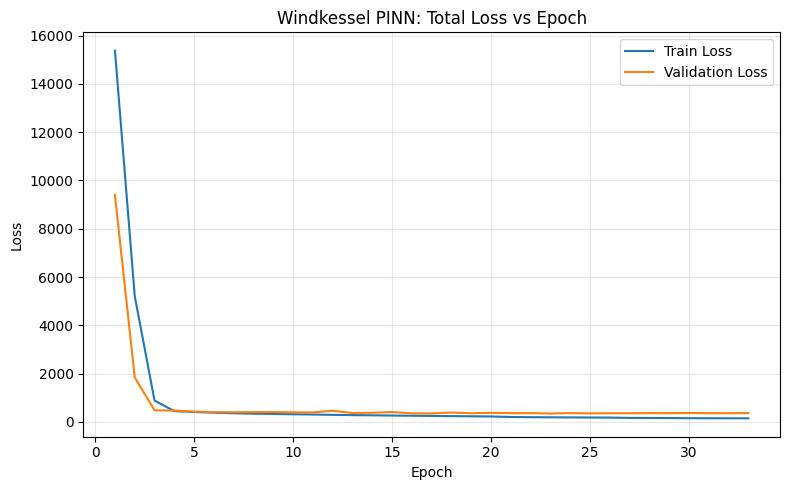

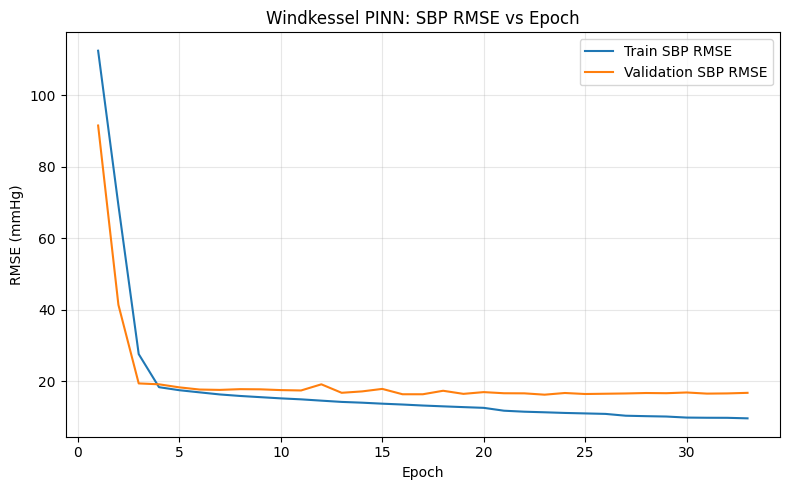

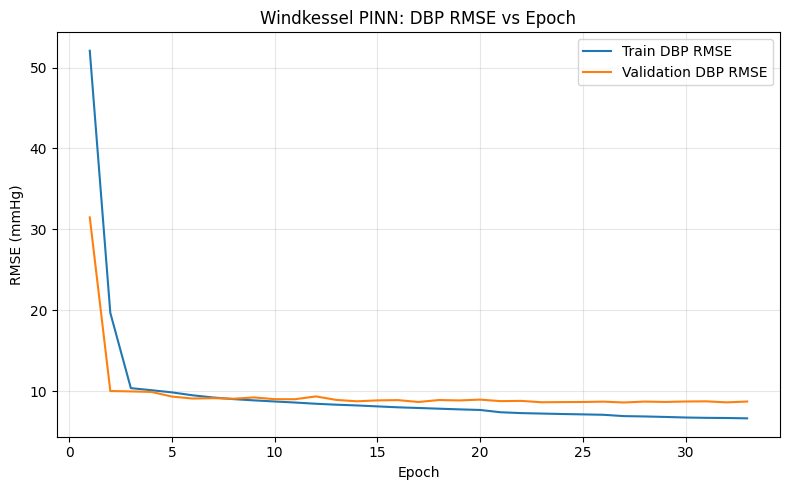

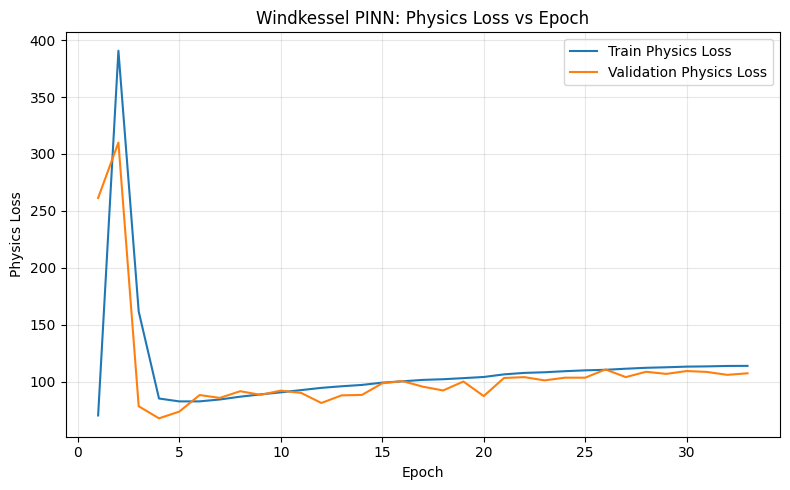

In [32]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16115.8084 | Train SBP MSE: 13131.6382 | Train DBP MSE: 2946.6721 | Train Phys: 37.4981 | Train RMSE: SBP=114.593, DBP=54.283 | Val Total: 11517.5748 | Val SBP MSE: 9769.6694 | Val DBP MSE: 1642.8162 | Val Phys: 105.0893 | Val RMSE: SBP=98.842, DBP=40.532 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6968.8954 | Train SBP MSE: 6002.6226 | Train DBP MSE: 790.5405 | Train Phys: 175.7323 | Train RMSE: SBP=77.477, DBP=28.117 | Val Total: 4076.7363 | Val SBP MSE: 3528.4630 | Val DBP MSE: 412.1825 | Val Phys: 136.0907 | Val RMSE: SBP=59.401, DBP=20.302 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1705.2103 | Train SBP MSE: 1411.7152 | Train DBP MSE: 188.7471 | Train Phys: 104.7480 | Train RMSE: SBP=37.573, DBP=13.739 | Val Total: 738.8084 | Val SBP MSE: 558.7010 | Val DBP MSE: 116.3257 | Val Phys: 63.7816 | Val RMSE: SBP=23.637, DBP=10.785 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 539.9722 | Train SBP MSE: 376.5486 | Train DBP MSE: 1

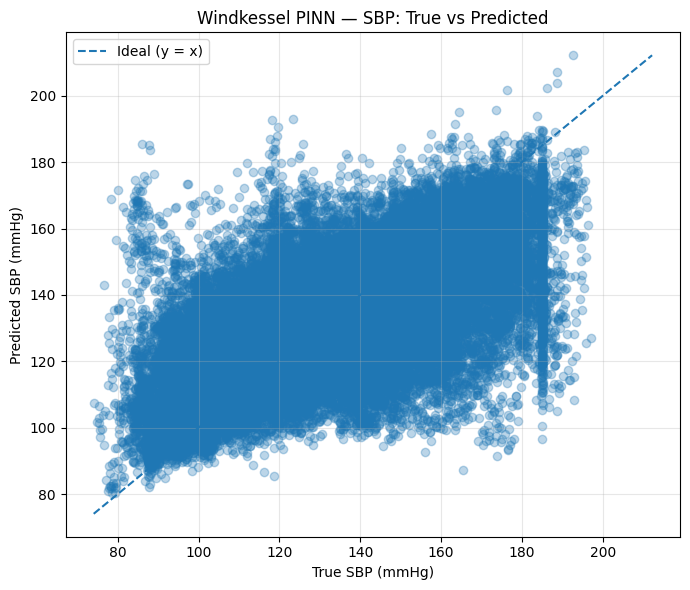

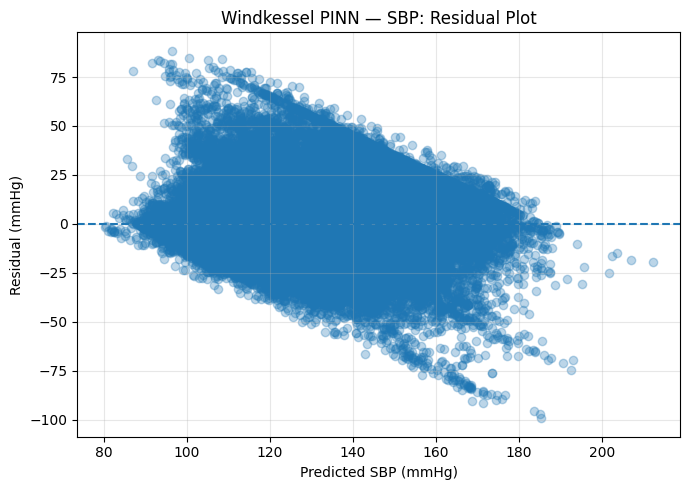

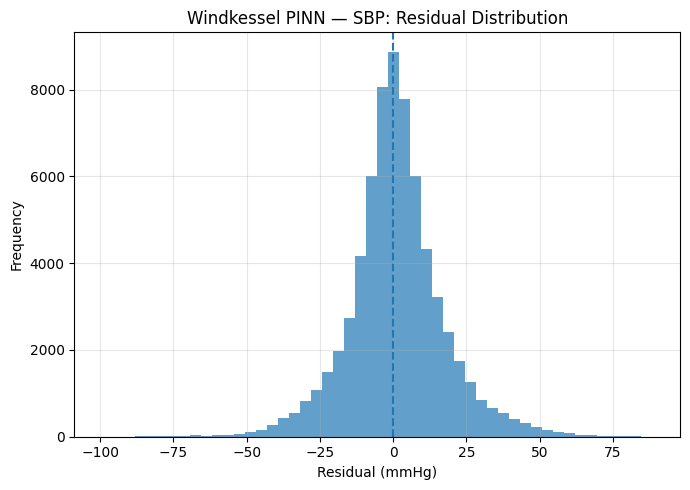

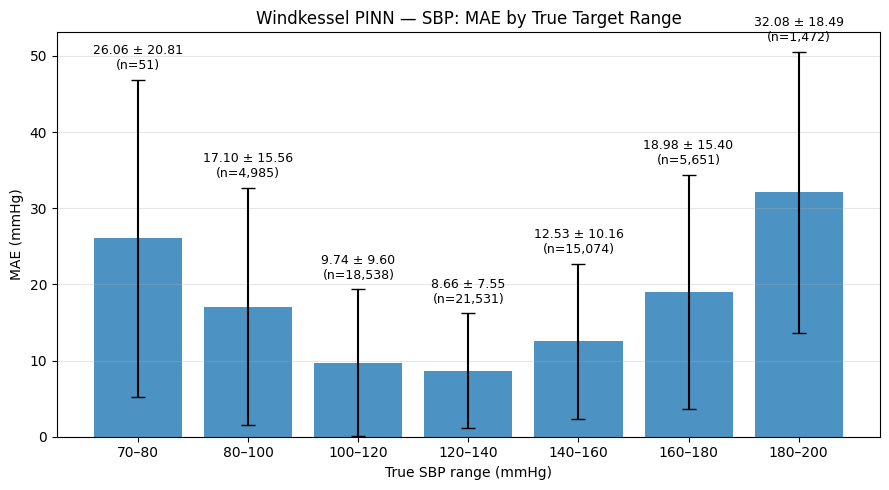


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.6400
MSE : 92.9294
R²  : 0.2509
MAE : 7.0707


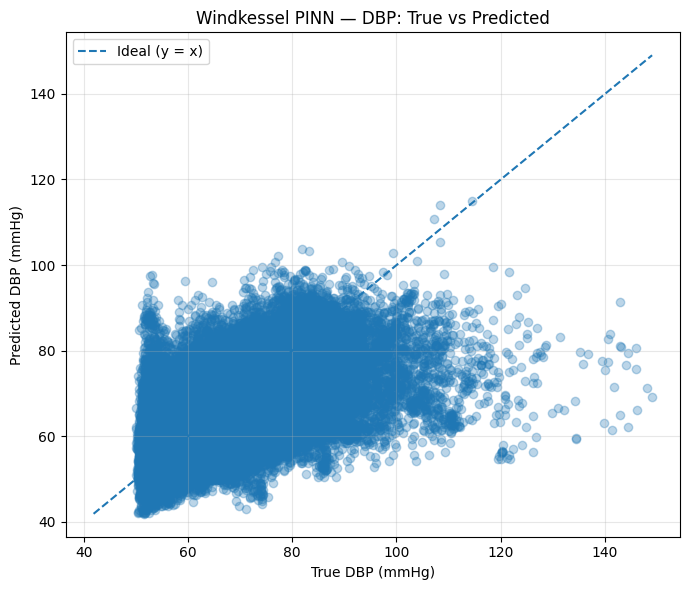

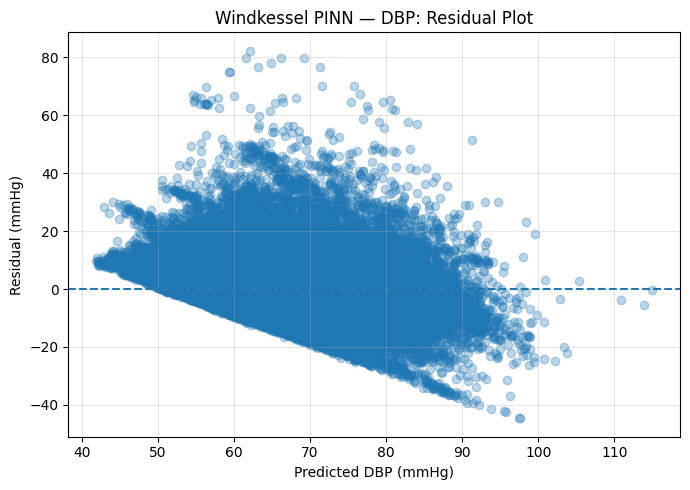

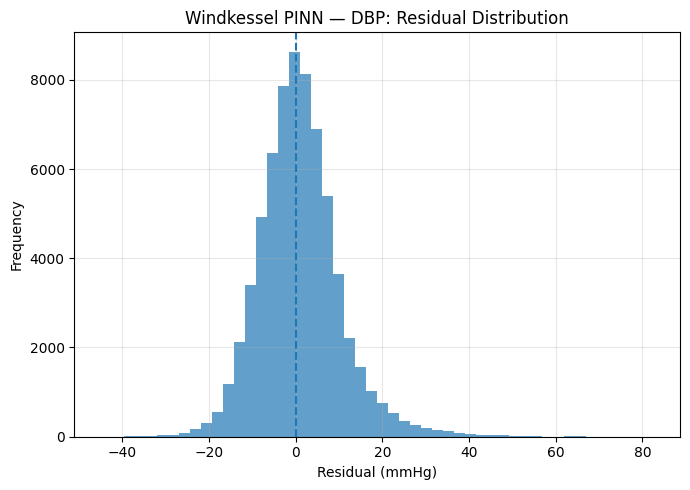

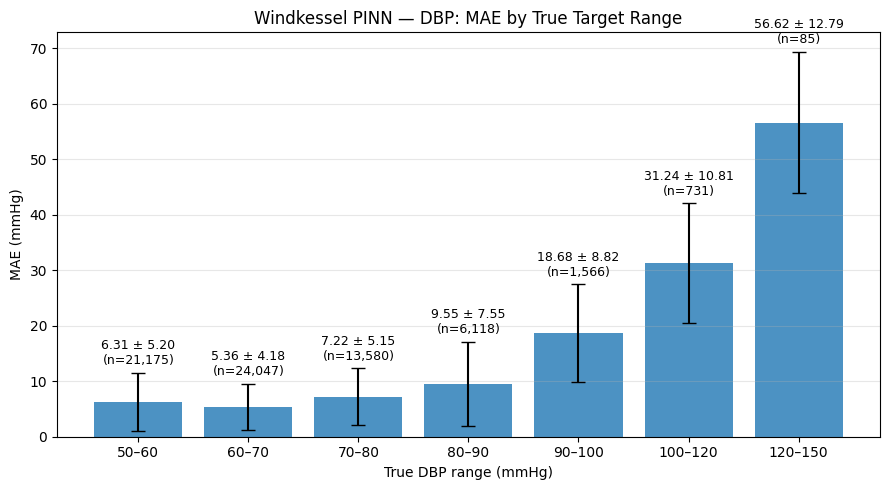

In [33]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=1
)

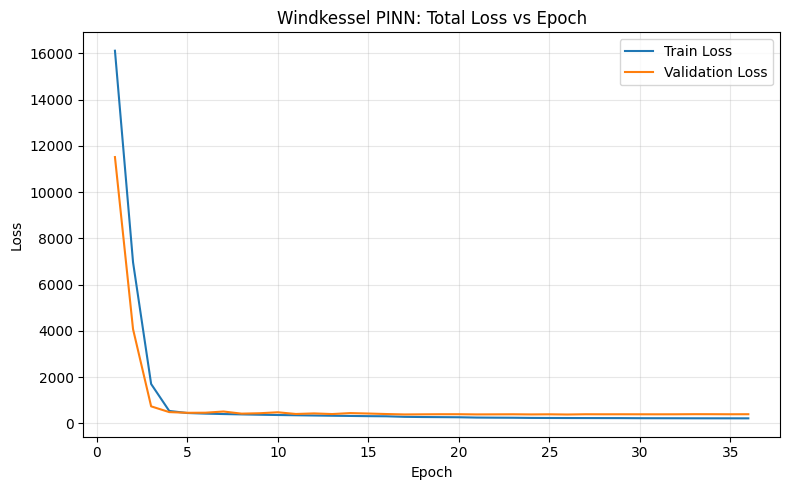

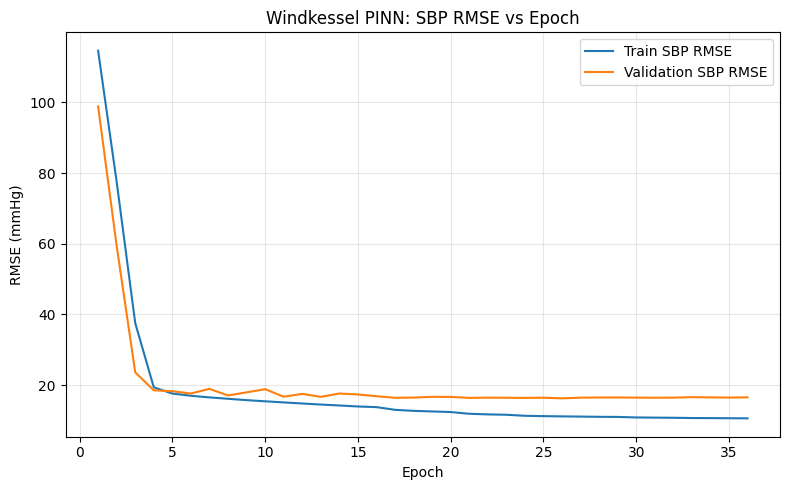

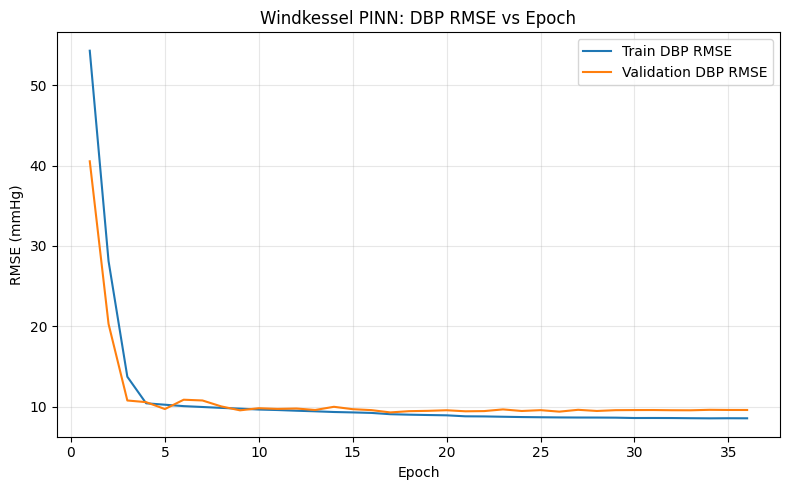

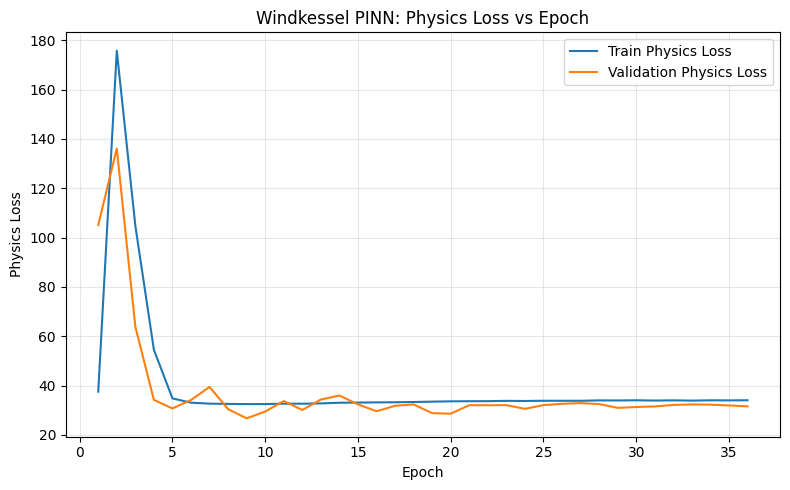

In [34]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16156.4755 | Train SBP MSE: 12918.1319 | Train DBP MSE: 3150.7870 | Train Phys: 8.7557 | Train RMSE: SBP=113.658, DBP=56.132 | Val Total: 11625.8844 | Val SBP MSE: 9365.0650 | Val DBP MSE: 2105.5977 | Val Phys: 15.5222 | Val RMSE: SBP=96.773, DBP=45.887 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 7310.2224 | Train SBP MSE: 5815.4975 | Train DBP MSE: 1334.3685 | Train Phys: 16.0356 | Train RMSE: SBP=76.259, DBP=36.529 | Val Total: 4129.1529 | Val SBP MSE: 3277.5473 | Val DBP MSE: 680.0113 | Val Phys: 17.1594 | Val RMSE: SBP=57.250, DBP=26.077 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1819.7726 | Train SBP MSE: 1333.1937 | Train DBP MSE: 349.9713 | Train Phys: 13.6608 | Train RMSE: SBP=36.513, DBP=18.708 | Val Total: 784.9242 | Val SBP MSE: 522.2785 | Val DBP MSE: 140.6548 | Val Phys: 12.1991 | Val RMSE: SBP=22.853, DBP=11.860 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 693.3604 | Train SBP MSE: 410.6423 | Train DBP MSE: 157.1

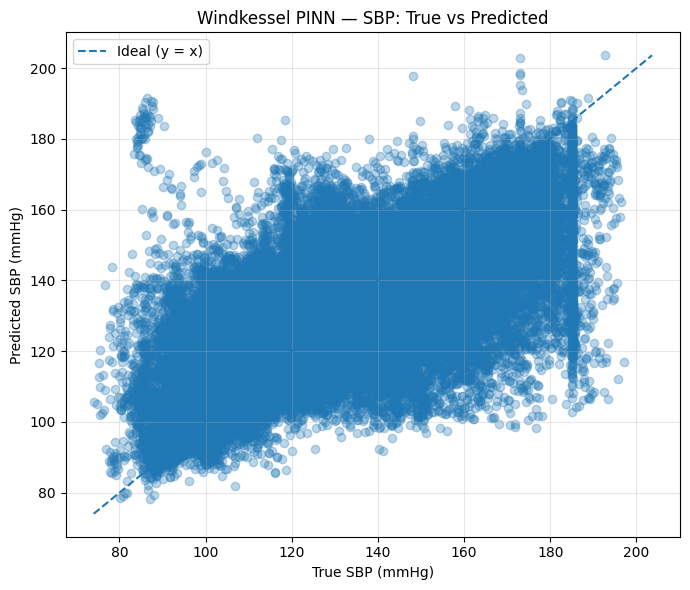

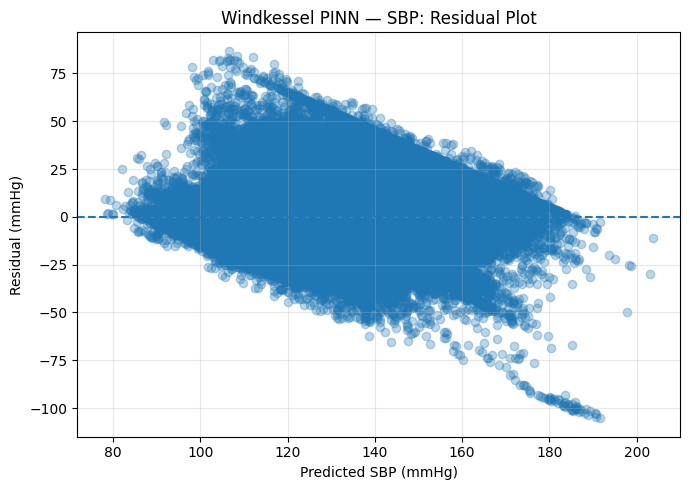

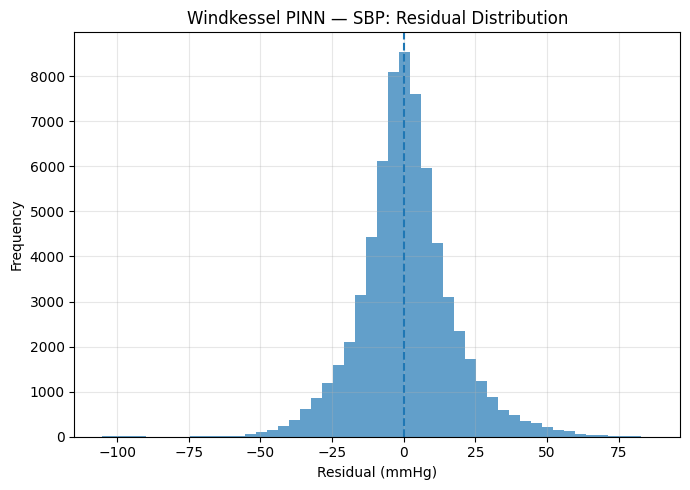

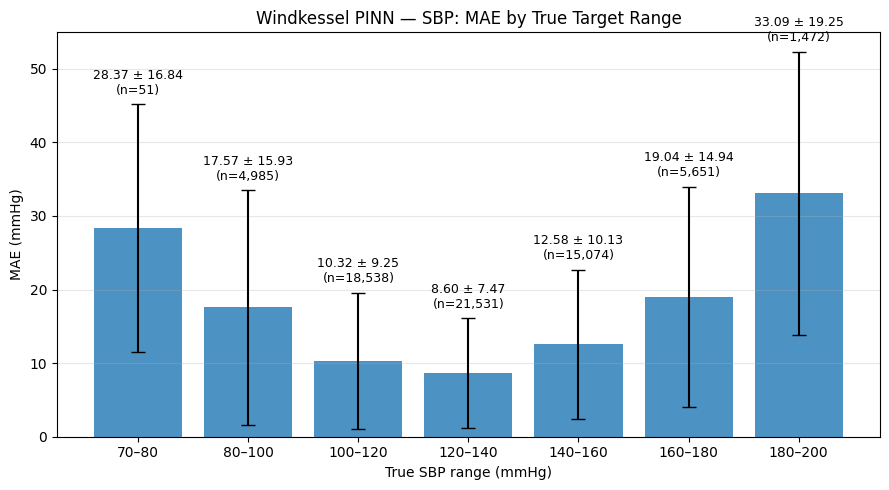


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 11.8022
MSE : 139.2925
R²  : -0.1229
MAE : 9.1541


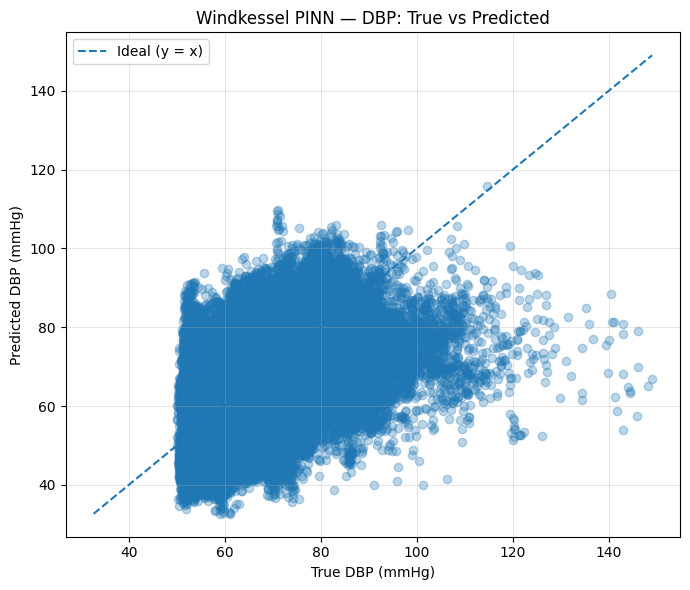

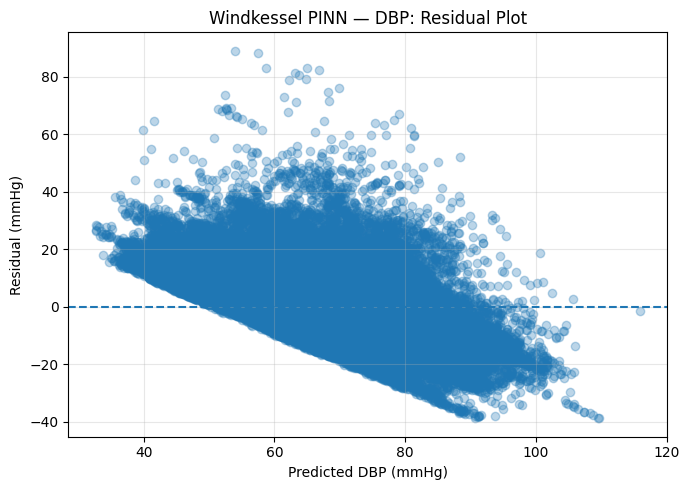

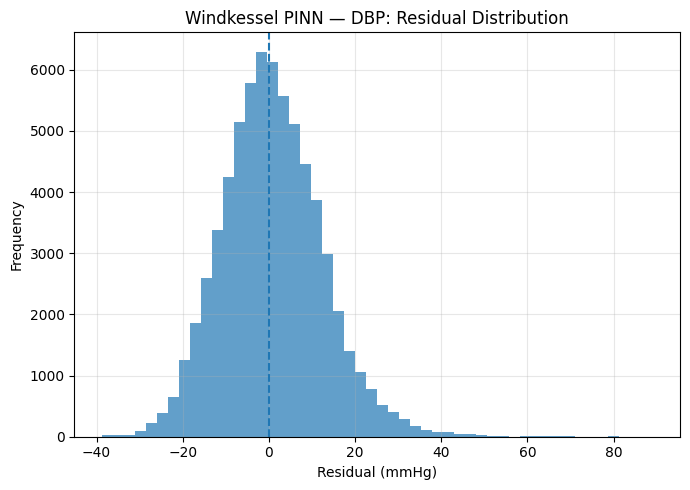

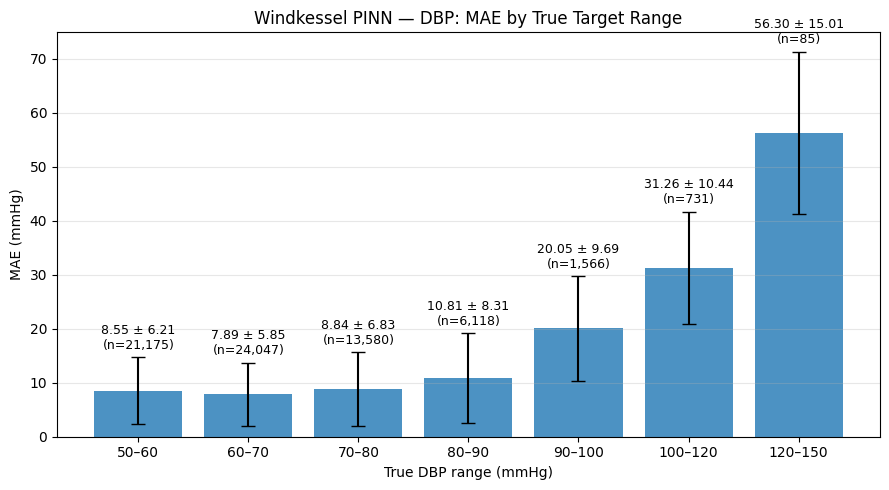

In [35]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=10
)

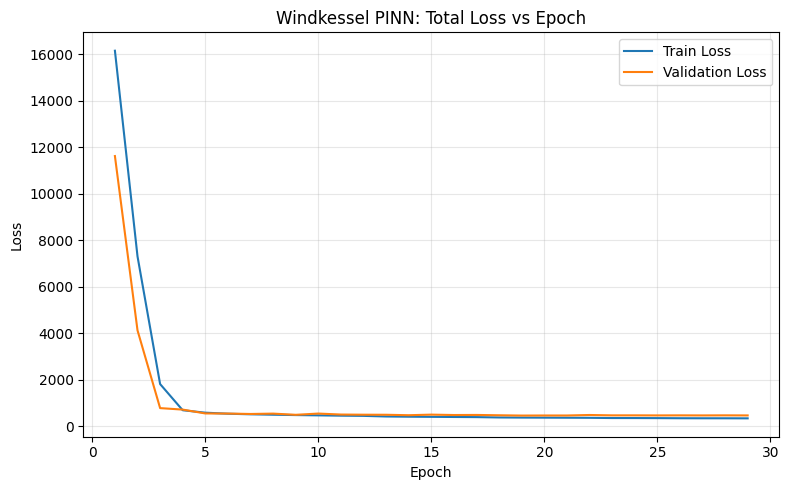

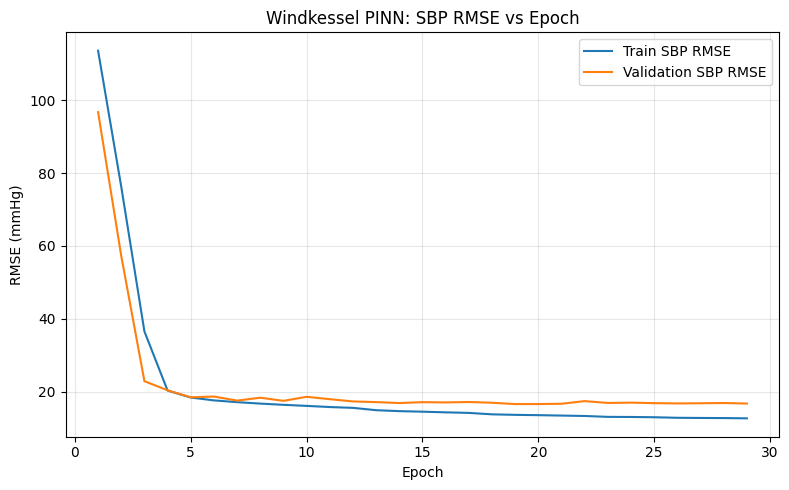

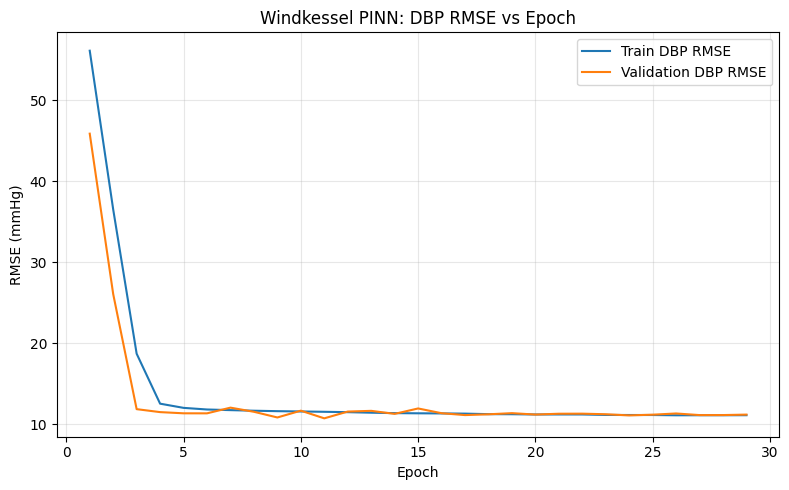

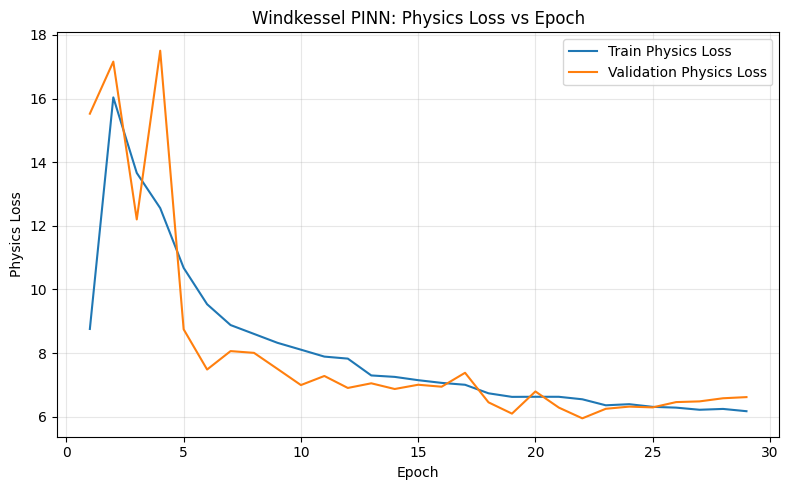

In [36]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16434.1287 | Train SBP MSE: 12977.7988 | Train DBP MSE: 3357.5906 | Train Phys: 0.9874 | Train RMSE: SBP=113.920, DBP=57.945 | Val Total: 10817.8821 | Val SBP MSE: 8490.5406 | Val DBP MSE: 2139.1321 | Val Phys: 1.8821 | Val RMSE: SBP=92.144, DBP=46.251 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 7271.9735 | Train SBP MSE: 5547.6215 | Train DBP MSE: 1455.2146 | Train Phys: 2.6914 | Train RMSE: SBP=74.482, DBP=38.147 | Val Total: 3386.0536 | Val SBP MSE: 2339.1801 | Val DBP MSE: 572.2693 | Val Phys: 4.7460 | Val RMSE: SBP=48.365, DBP=23.922 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 2792.0547 | Train SBP MSE: 1822.8358 | Train DBP MSE: 520.2567 | Train Phys: 4.4896 | Train RMSE: SBP=42.695, DBP=22.809 | Val Total: 1516.0655 | Val SBP MSE: 799.9632 | Val DBP MSE: 242.2151 | Val Phys: 4.7389 | Val RMSE: SBP=28.284, DBP=15.563 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 1523.3517 | Train SBP MSE: 736.3660 | Train DBP MSE: 249.9144

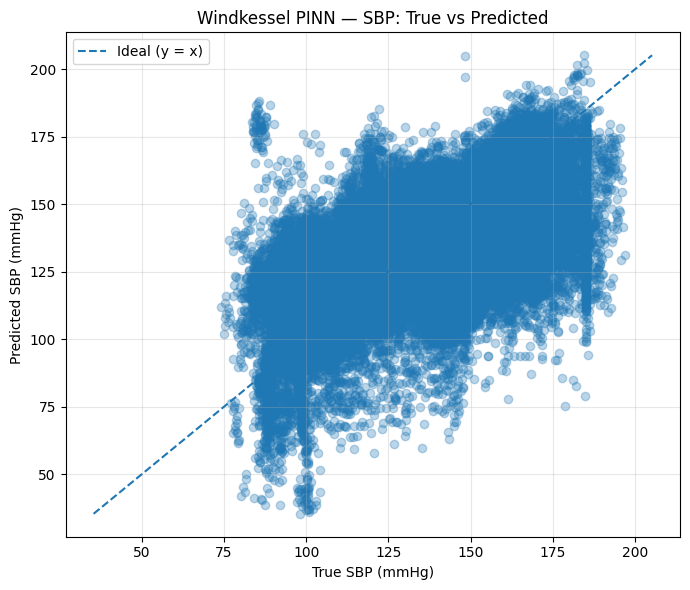

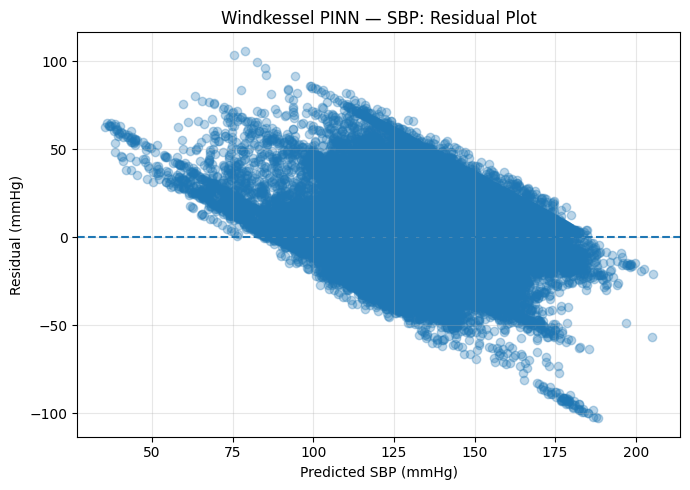

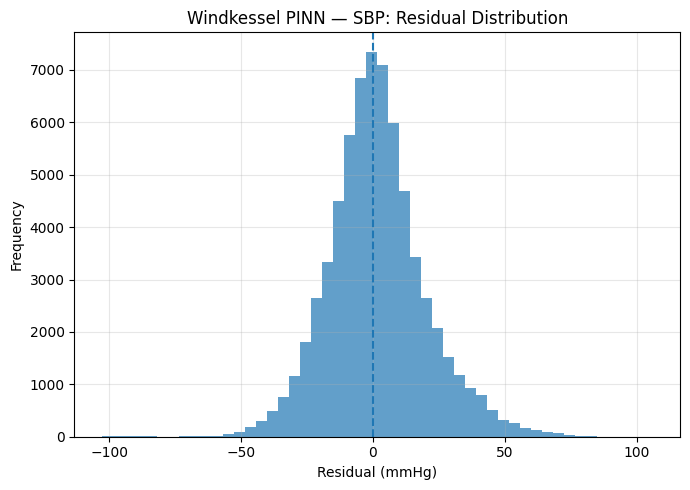

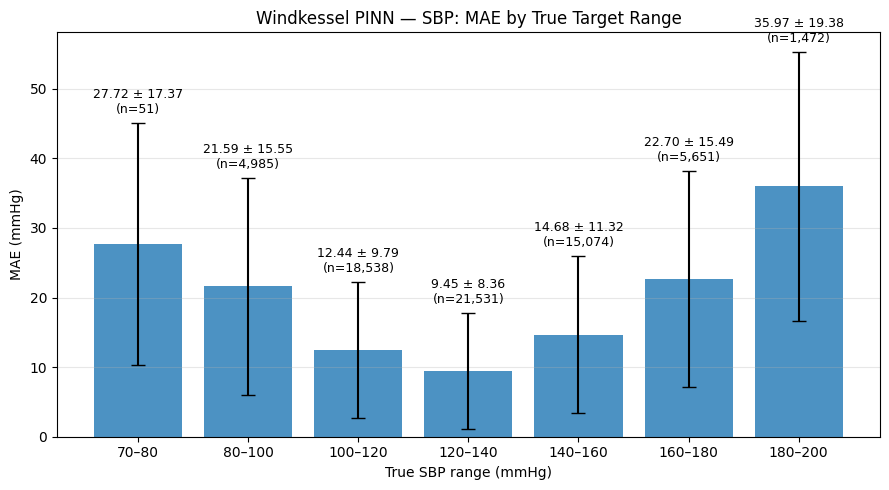


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 12.2467
MSE : 149.9811
R²  : -0.2090
MAE : 9.3141


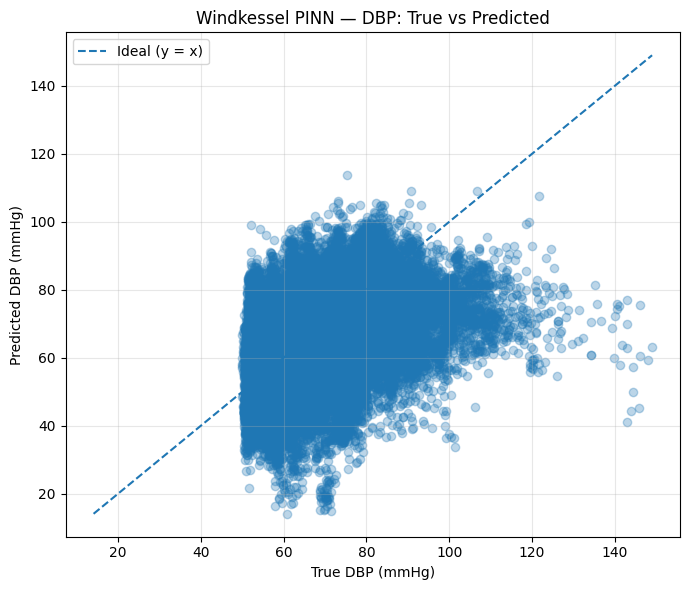

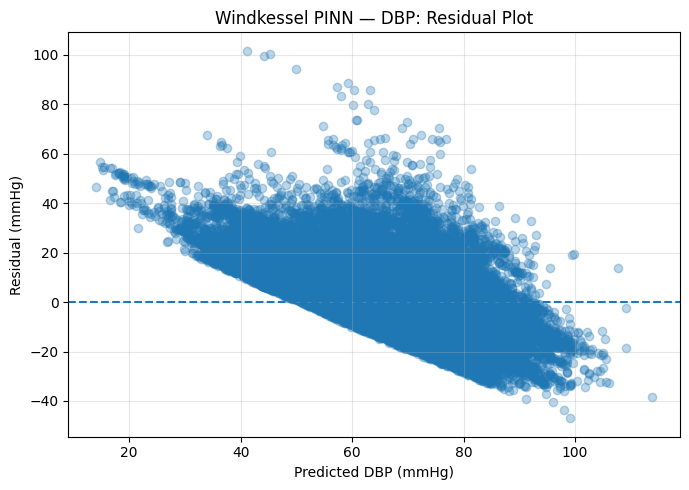

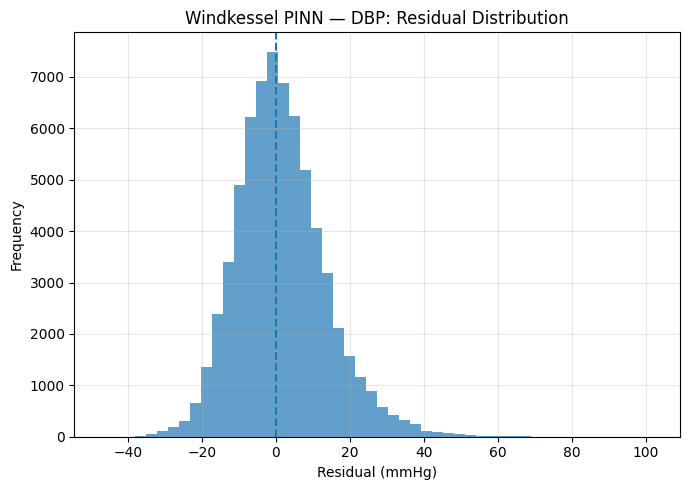

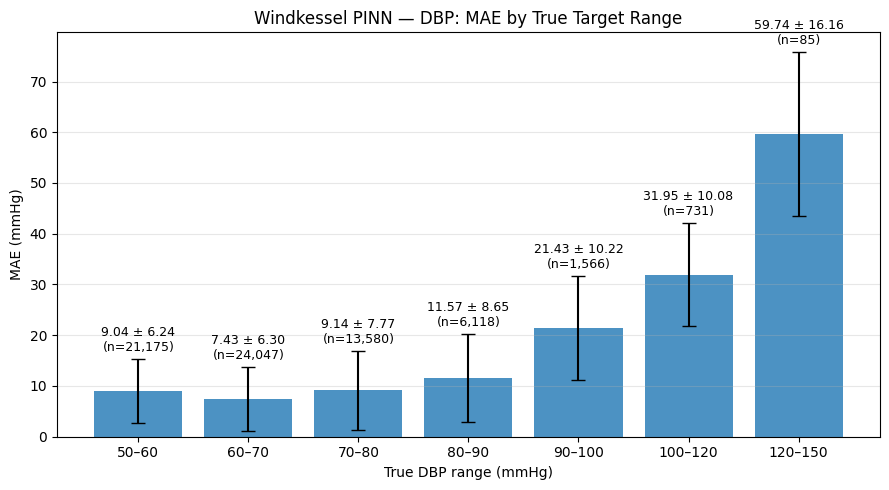

In [37]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=100
)

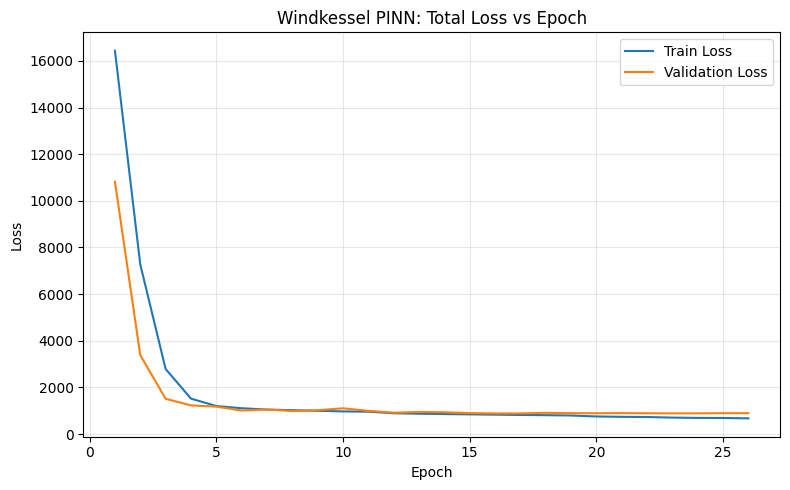

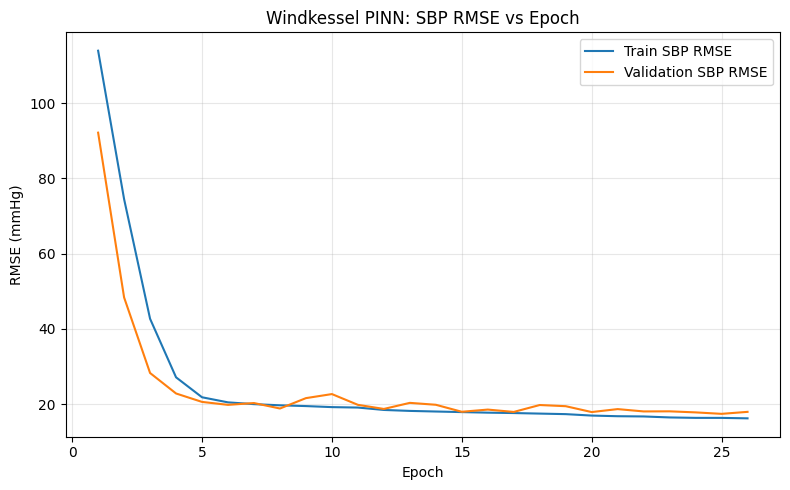

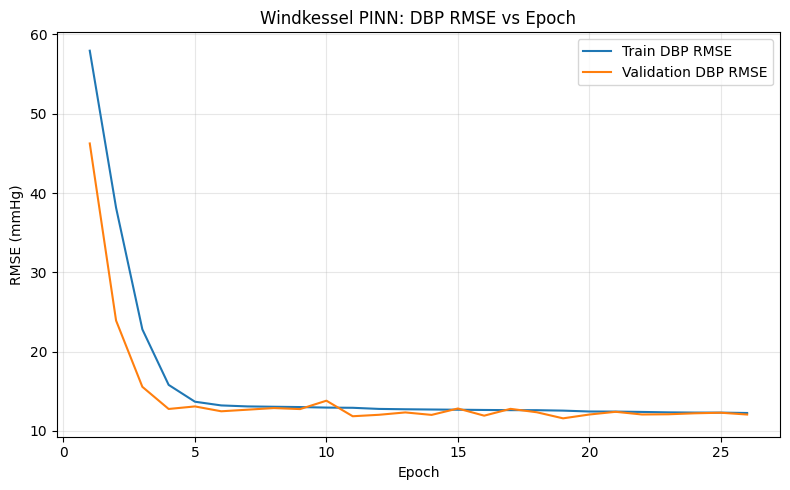

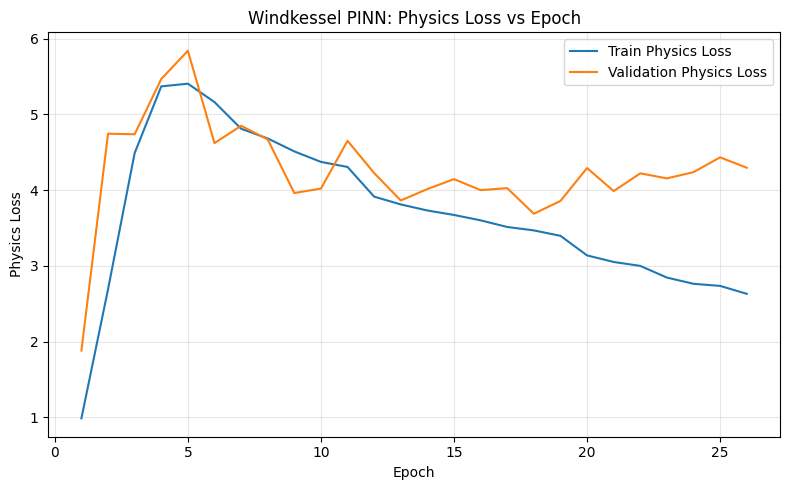

In [38]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)